# Offensive IT-Tester: Week 1 + Week 2 Deliverable
### Responsible AI & Data Ethics — SRH Heidelberg, SS2026

**Course:** PEL — Responsible AI and Data Ethics (Prof. Simon Geschwill)  
**Project:** Offensive IT-Tester Agent  
**Dataset:** [Web Application Payloads Dataset](https://www.kaggle.com/datasets/cyberprince/web-application-payloads-dataset)

---

**Scope statement.** All payloads tested **only** against self-hosted authorized lab targets (DVWA, OWASP Juice Shop, WebGoat). No production systems. No novel payload generation. Every action logged, scope-gated, human-approvable.

---

**Week 1:** Data analysis → Project plan → Architecture → Regulatory analysis  
**Week 2:** Baseline model → Risk analysis → Fairness analysis

# WEEK 1

# 1. Data Analysis

## 1.0 Setup and Imports

In [1]:
import json, re, hashlib, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy import stats
from scipy.stats import entropy

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'figure.titlesize': 15})

CLASS_ORDER = ['SQLi', 'XSS', 'CSRF', 'SSRF', 'CmdInj']
PALETTE = dict(zip(CLASS_ORDER, ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']))
SEV_COLORS = {'low':'#cccccc','medium':'#ffd166','high':'#ef8a62','critical':'#b2182b'}

print('Setup complete.')

Setup complete.


## 1.1 Loading and Data Integrity

The raw file has four parsing defects. This defensive loader repairs all four.

In [2]:
def load_payloads(path='WEB_APPLICATION_PAYLOADS.jsonl'):
    raw = open(path, encoding='utf-8').read()
    s = raw.replace('\u00a0', ' ').replace('\r', '')   # NBSP -> space, drop CR
    s = re.sub(r'(?<!\\)\\x', r'\\\\x', s)         # fix lone invalid \x escape
    s = re.sub(r'}\s*\n\s*{', '},\n{', s)              # missing commas between objects
    s = re.sub(r',(\s*[}\]])', r'\1', s)                # trailing commas
    return json.loads(s)

records = load_payloads()
CAT = {'sqli':'SQLi','xss':'XSS','csrf':'CSRF','ssrf':'SSRF','cmdinj':'CmdInj'}
df = pd.DataFrame(records)
df['attack_class'] = df['id'].str.split('-').str[0].map(CAT)
df['payload'] = df['payload'].fillna('')
df['plen'] = df['payload'].str.len()

print('records:', len(df))
print('columns:', list(df.columns))
df.head(3)

records: 500
columns: ['id', 'description', 'payload', 'context', 'type', 'severity', 'example_query', 'example_usage', 'attack_class', 'plen']


,id,description,payload,context,type,severity,example_query,example_usage,attack_class,plen
0,sqli-001,Basic tautology-based SQL injection,' OR '1'='1,Login form username input,tautology,high,SELECT * FROM users WHERE username = '' OR '1'...,NaN,SQLi,11
1,sqli-002,Union-based SQL injection to extract data,"' UNION SELECT username, password FROM users--",Search input field,union,high,"SELECT name, description FROM products WHERE n...",NaN,SQLi,46
2,sqli-003,Blind SQL injection with time delay,'; WAITFOR DELAY '0:0:5'--,ID parameter in URL,blind-time,medium,SELECT * FROM orders WHERE id = ''; WAITFOR DE...,NaN,SQLi,26


## 1.2 Data Quality Audit

In [3]:
empty = df[df['payload'] == '']
print(f'Empty payloads: {len(empty)} -> IDs: {empty["id"].tolist()}')

dupe_mask = df['payload'].duplicated(keep=False) & (df['payload'] != '')
n_dupe = int(dupe_mask.sum())
n_distinct_dupes = df.loc[dupe_mask, 'payload'].nunique()
print(f'\nDuplicate payloads: {n_dupe} rows ({n_distinct_dupes} distinct strings repeated)')
print('\nDuplicate concentration by class:')
print(df[dupe_mask]['attack_class'].value_counts())
print(f'\nUnique contexts: {df["context"].nunique()}')

Empty payloads: 1 -> IDs: ['csrf-039']

Duplicate payloads: 78 rows (34 distinct strings repeated)

Duplicate concentration by class:
attack_class
SSRF      29
CmdInj    22
SQLi      20
CSRF       7
Name: count, dtype: int64

Unique contexts: 245


**Finding.** One CSRF record (`csrf-039`) empty. 60+ duplicates, concentrated in SSRF/CmdInj. Decision: deduplicate before modelling.

## 1.3 Class Distribution and Severity

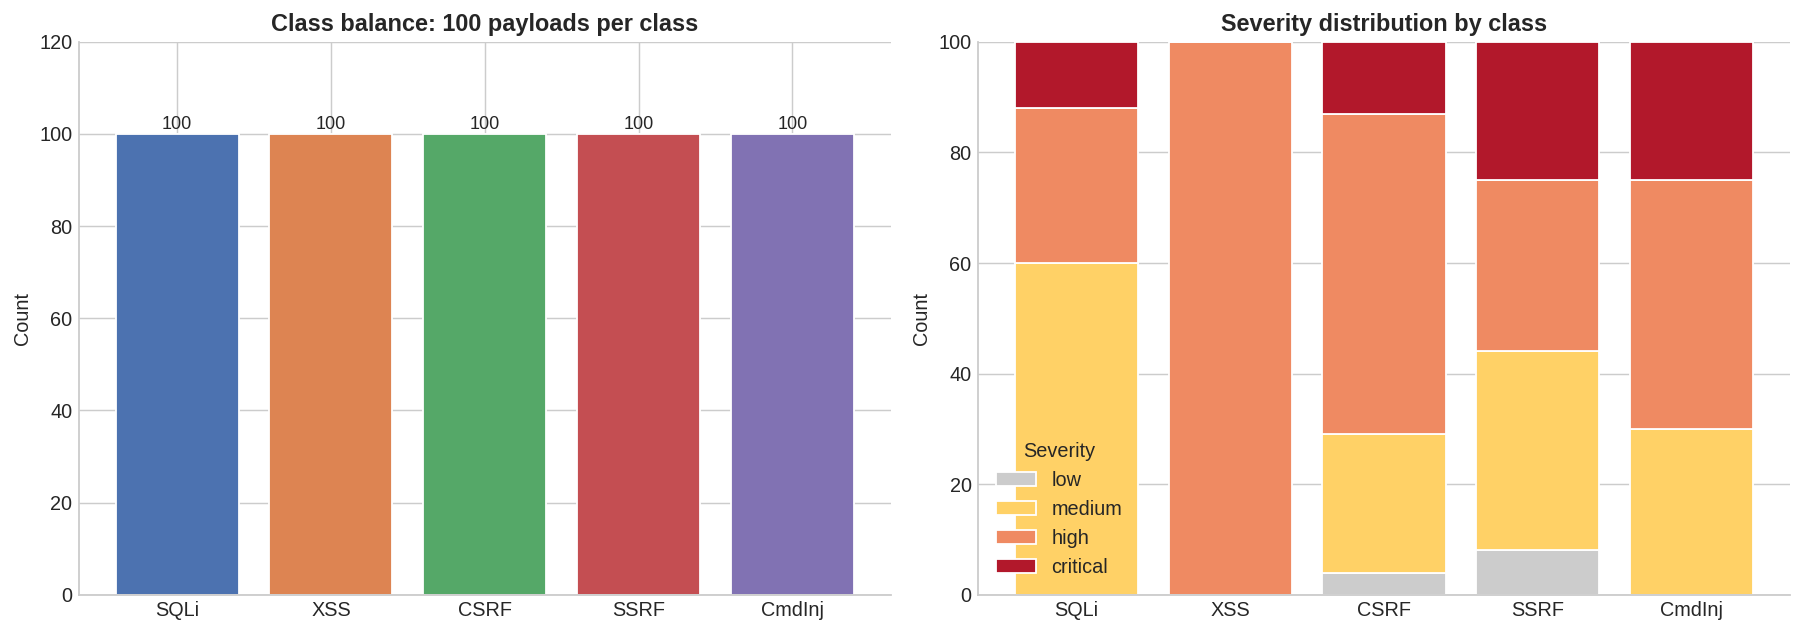

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cc = df['attack_class'].value_counts().reindex(CLASS_ORDER)
bars = axes[0].bar(cc.index, cc.values, color=[PALETTE[c] for c in cc.index], edgecolor='white')
for b, v in zip(bars, cc.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+1, str(v), ha='center', fontsize=10)
axes[0].set_title('Class balance: 100 payloads per class')
axes[0].set_ylabel('Count'); axes[0].set_ylim(0, 120)
axes[0].spines[['top','right']].set_visible(False)

sev_order = ['low','medium','high','critical']
piv = (df.pivot_table(index='attack_class', columns='severity', values='id',
                      aggfunc='count', fill_value=0).reindex(CLASS_ORDER)[sev_order])
bottom = np.zeros(len(piv))
for s in sev_order:
    axes[1].bar(piv.index, piv[s], bottom=bottom, label=s, color=SEV_COLORS[s], edgecolor='white')
    bottom += piv[s].values
axes[1].set_title('Severity distribution by class')
axes[1].set_ylabel('Count'); axes[1].legend(title='Severity')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

**Findings:** Balanced at 100/class. XSS uniformly `high` = labelling artefact. SSRF/CmdInj carry most `critical` labels.

## 1.4 Attack Sub-Types

In [5]:
for c in CLASS_ORDER:
    t = df[df.attack_class==c]['type'].value_counts()
    print(f'{c:7s} ({len(t)} types): ' + ', '.join(f'{k}={v}' for k,v in t.items()))

SQLi    (6 types): blind-time=33, tautology=19, union=19, boolean-blind=13, stacked-queries=12, error-based=4
XSS     (2 types): reflected=54, stored=46
CSRF    (1 types): CSRF=100
SSRF    (1 types): SSRF=100
CmdInj  (1 types): Command Injection=100


## 1.5 Payload Length Analysis

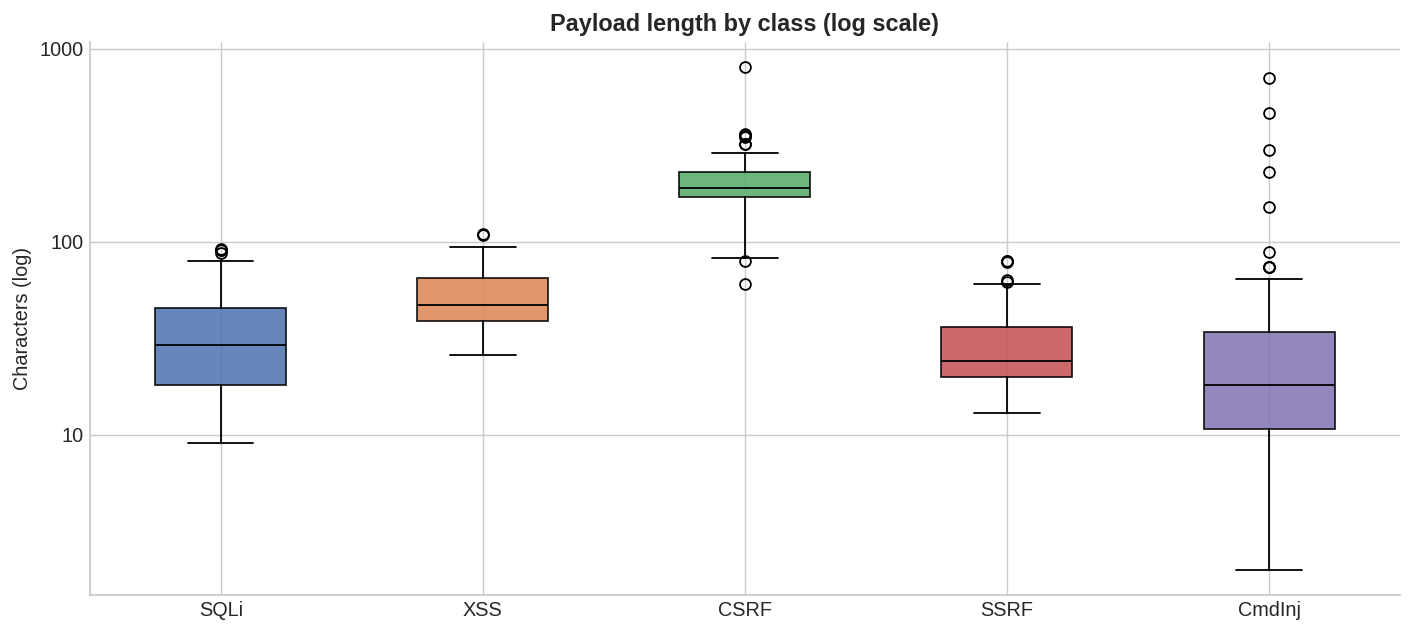

               min    50%    max
attack_class                    
SQLi           9.0   29.0   92.0
XSS           26.0   47.0  109.0
CSRF           0.0  189.0  804.0
SSRF          13.0   24.0   79.0
CmdInj         2.0   18.0  701.0


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
data = [df[df.attack_class==c]['plen'].values for c in CLASS_ORDER]
parts = ax.boxplot(data, labels=CLASS_ORDER, patch_artist=True, showfliers=True,
                   medianprops=dict(color='black'))
for patch, c in zip(parts['boxes'], CLASS_ORDER):
    patch.set_facecolor(PALETTE[c]); patch.set_alpha(0.85)
ax.set_yscale('log')
ax.set_title('Payload length by class (log scale)')
ax.set_ylabel('Characters (log)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print(df.groupby('attack_class')['plen'].describe()[['min','50%','max']].reindex(CLASS_ORDER))

## 1.6 Character Signatures — Key Finding

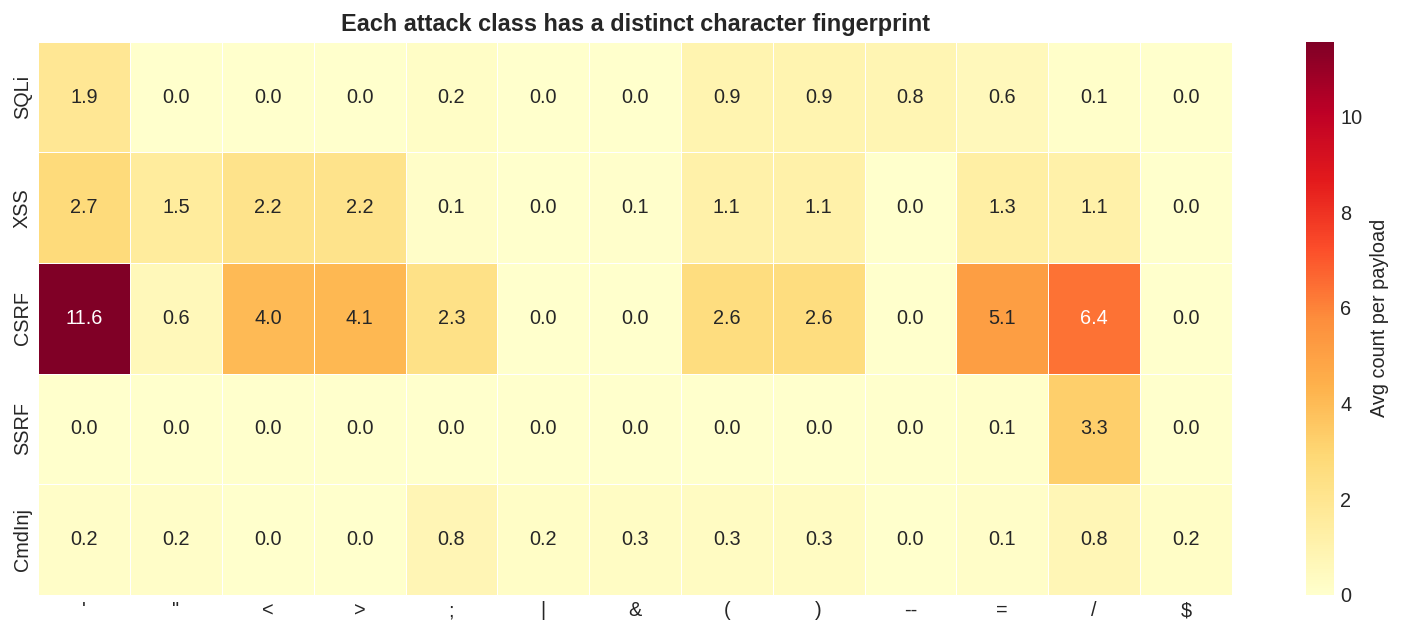

In [7]:
sig_chars = ["'", '"', '<', '>', ';', '|', '&', '(', ')', '--', '=', '/', '$']
sig = pd.DataFrame(index=CLASS_ORDER, columns=sig_chars, dtype=float)
for c in CLASS_ORDER:
    pl = df[df.attack_class==c]['payload']
    for ch in sig_chars:
        sig.loc[c, ch] = pl.apply(lambda p: p.count(ch)).mean()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(sig.astype(float), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Avg count per payload'}, ax=ax)
ax.set_title('Each attack class has a distinct character fingerprint')
plt.tight_layout(); plt.show()

**SQLi:** `'` and `--`. **XSS:** `< >`. **CSRF:** high everywhere (HTML docs). **SSRF:** only `/`. **CmdInj:** `; | &`.

## 1.7 Statistical Validation

In [8]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

char_features = pd.DataFrame(index=df.index)
for ch in sig_chars:
    char_features[ch] = df['payload'].apply(lambda p: p.count(ch))

le = LabelEncoder()
y_all = le.fit_transform(df['attack_class'])

mi = mutual_info_classif(char_features.values, y_all, discrete_features=False, random_state=42)
mi_df = pd.DataFrame({'character': sig_chars, 'mutual_info': mi}).sort_values('mutual_info', ascending=False)
print('Mutual Information (higher = more discriminative):')
print(mi_df.to_string(index=False))

print('\nKruskal-Wallis H-test:')
for ch in sig_chars:
    groups = [df[df.attack_class==c]['payload'].apply(lambda p: p.count(ch)).values for c in CLASS_ORDER]
    h_stat, p_val = stats.kruskal(*groups)
    sig_marker = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    print(f'  {ch:4s}  H={h_stat:8.1f}  p={p_val:.2e}  {sig_marker}')

Mutual Information (higher = more discriminative):
character  mutual_info
        '     1.101977
        /     0.825309
        <     0.726448
        >     0.699069
        =     0.583817
        )     0.497060
        (     0.492452
       --     0.335365
        ;     0.318307
        "     0.242678
        $     0.055023
        &     0.041524
        |     0.011281

Kruskal-Wallis H-test:
  '     H=   427.2  p=3.65e-91  ***
  "     H=   248.4  p=1.46e-52  ***
  <     H=   462.0  p=1.13e-98  ***
  >     H=   454.0  p=5.94e-97  ***
  ;     H=   259.4  p=6.11e-55  ***
  |     H=    43.7  p=7.49e-09  ***
  &     H=    63.8  p=4.54e-13  ***
  (     H=   290.9  p=1.02e-61  ***
  )     H=   290.9  p=1.02e-61  ***
  --    H=   391.6  p=1.85e-83  ***
  =     H=   319.8  p=5.66e-68  ***
  /     H=   365.0  p=1.03e-77  ***
  $     H=    74.5  p=2.51e-15  ***


## 1.8 Target Injection Contexts

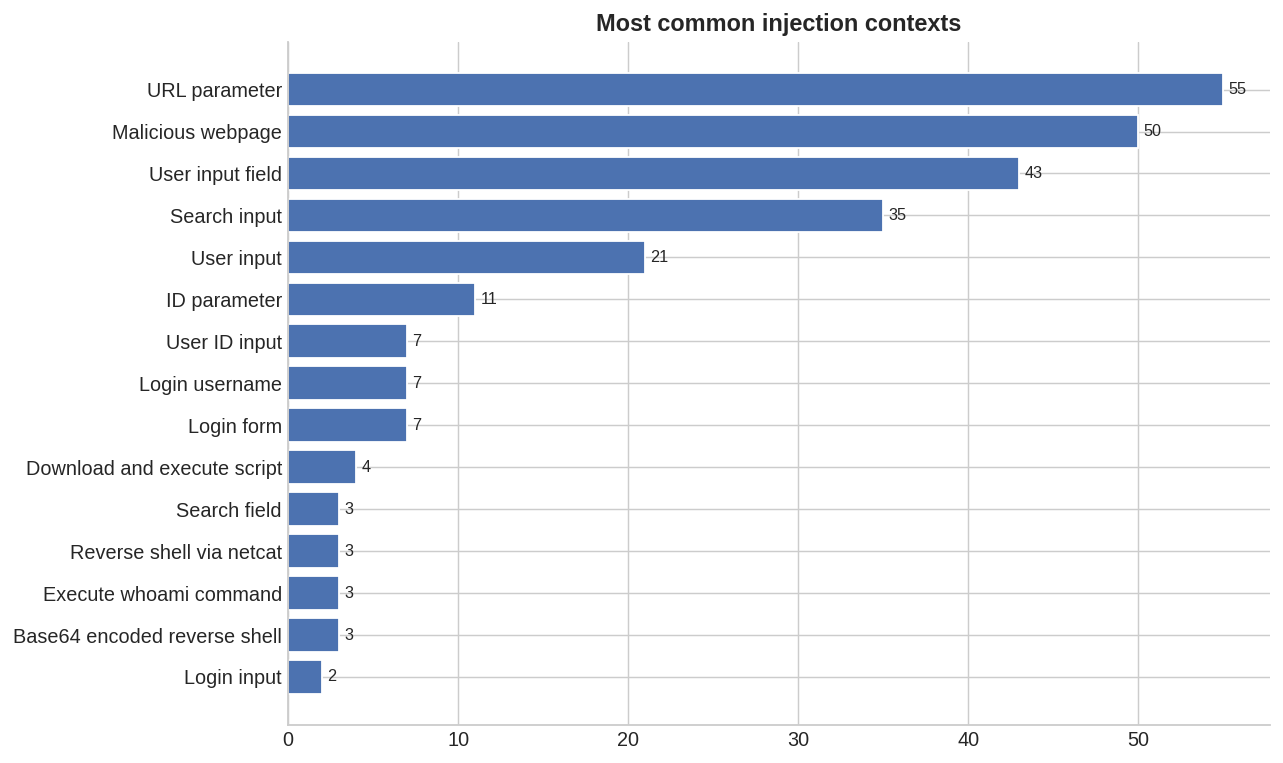

Distinct contexts: 245


In [9]:
top_ctx = df['context'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_ctx.index[::-1], top_ctx.values[::-1], color='#4C72B0', edgecolor='white')
for i, v in enumerate(top_ctx.values[::-1]):
    ax.text(v+0.3, i, str(v), va='center', fontsize=9)
ax.set_title('Most common injection contexts')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f'Distinct contexts: {df["context"].nunique()}')

## 1.9 Reproducible Corpus Cleaning

In [10]:
clean = df[df['payload'] != ''].copy()
clean['norm'] = clean['payload'].str.replace(r'\s+', ' ', regex=True).str.strip().str.lower()
clean['payload_hash'] = clean['norm'].apply(lambda t: hashlib.sha1(t.encode()).hexdigest()[:12])
clean_dedup = clean.drop_duplicates('payload')

print(f'Non-empty payloads:        {len(clean)}')
print(f'Unique (exact string):     {len(clean_dedup)}')
print(f'Unique (normalised hash):  {clean["payload_hash"].nunique()}')

clean_dedup[['id','attack_class','type','severity','context','payload_hash','payload']].to_csv(
    'payloads_clean.csv', index=False)
print(f'\nWrote payloads_clean.csv with {len(clean_dedup)} rows')
print(clean_dedup['attack_class'].value_counts().reindex(CLASS_ORDER))

Non-empty payloads:        499
Unique (exact string):     455
Unique (normalised hash):  454

Wrote payloads_clean.csv with 455 rows
attack_class
SQLi       87
XSS       100
CSRF       95
SSRF       85
CmdInj     88
Name: count, dtype: int64


## 1.10 Data Decisions Summary

1. **Five classes, not three.** CSRF + SSRF added.
2. **Dedupe** → ~455 unique payloads.
3. **Severity unreliable** (XSS bias).
4. **Five detectors needed**, one per class.
5. **Character signatures = free baseline.**
6. **Scope gate first** — CmdInj/SSRF are critical.

# 2. Project Plan

| Phase | Work | Acceptance |
|---|---|---|
| 0. Governance | Authorization, allowlist, kill switch | No request without scope |
| 1. Data prep | Clean, dedupe, version | Clean CSV, hash splitting |
| 2. Baseline | Char + TF-IDF classifier | >=90% F1 5-fold CV |
| 3. Scope gate | Deterministic allowlist | 100% out-of-scope refusal |
| 4. Detectors | 5 per-class modules vs DVWA | Per-class P/R |
| 5. LLM planner | Context->template->plan | Structured output only |
| 6. Guardrails | Scope + injection testing | Measured numbers |
| 7. Docs | Model card, pitch | Runnable notebook |

# 3. Architecture

**Revision note:** the diagram below replaces an earlier draft. It is the same seven
functional layers, redrawn so the diagram and the executable agent in Section 5C
describe the same system, and so it fits on one presentation slide.

```mermaid
flowchart TD
    URL([Target URL]) --> AUTH{{Authorization gate}}
    AUTH -->|rejected| STOP([Stop: out of scope])
    AUTH -->|approved| RECON[Recon: find injection points]
    RECON --> SELECT[Select payload -- LLM planner]
    SELECT --> GOV{{Governance gate<br/>severity + rate limit}}
    GOV -->|rejected| SELECT
    GOV -->|approved| EXEC[Fire payload + capture response]
    EXEC --> DETECT[Detect: vulnerable? confidence]
    DETECT -->|budget/targets remain| SELECT
    DETECT -->|done| REPORT[/Report + audit log/]

    classDef gate fill:#FAEEDA,stroke:#BA7517,color:#633806;
    classDef stopnode fill:#FCEBEB,stroke:#A32D2D,color:#791F1F;
    class AUTH,GOV gate;
    class STOP stopnode;
```

**What each box actually is, in the code (Section 5C):**

| Box | Implementation |
|---|---|
| Authorization gate | `ScopeGate.check()` -- five checks in one gate: authorized host, authorized port, allowed HTTP method, inside the test time-window, and no destructive-payload content. Rate limiting is enforced here too. |
| Recon | `recon_node`, calls the `enumerate_surfaces` tool against the target |
| Select payload | `plan_node`, calls an **LLM planner** that reasons over the target surface and the reviewed payload corpus (Section 3.1) |
| Governance gate | `governance_node`, calls the same `ScopeGate.check()` tool a second time, this time against the *specific* payload the planner chose |
| Fire payload | `execute_node`, calls the `fire_payload` tool (HTTP only, sandboxed; a mock target in this notebook, a real DVWA/Juice Shop instance in Week 3) |
| Detect | `detect_node`, calls the `detect_vulnerability` tool, one of five non-destructive, per-class checkers |
| Report | `report_node`, plus every node above writes to the immutable audit log via the `log_audit` tool |

**Why this is an agent and not a classifier.** A classifier answers one question about
one string in isolation. This system perceives a live target (recon), plans a sequence
of actions under uncertainty (the LLM planner, reasoning over which payload fits which
surface), acts on the target and observes the result (execute), and judges that result
to decide the next action (detect feeds back into plan). The classifier from Section 5
is one tool this agent calls, not the agent itself.

# 4. Regulatory Analysis

## 4.1 German Criminal Law

| Statute | Coverage | Control |
|---|---|---|
| StGB §202a | Unauthorized access | Only authorized systems |
| StGB §202b | Data interception | No interception outside lab |
| StGB §202c | Hackerparagraf | Documented authorization |
| StGB §303a | Data manipulation | Non-destructive only |
| StGB §303b | Computer sabotage | No DoS/destruction |

## 4.2 EU AI Act

Most likely minimal/limited risk. High-risk controls applied voluntarily:

| Article | Our Implementation |
|---|---|
| Art. 9 Risk mgmt | Risk analysis + threat model |
| Art. 12 Records | Immutable audit log |
| Art. 14 Human oversight | Scope gate + approval + kill switch |
| Art. 15 Robustness | Template registry + guardrail metrics |

## 4.3 Framework Mapping

In [11]:
pd.set_option('display.max_colwidth', None)
fm = pd.DataFrame([
    ['Auth & scope gate',        'LLM06 Excessive Agency',      'AML.M0020 Guardrails',     'GOVERN/MANAGE', 'Art. 14'],
    ['Template registry',        'LLM05 Improper Output',       'AML.M0020 Guardrails',     'MANAGE',        'Art. 15'],
    ['LLM proposes, determ exec','LLM06 Excessive Agency',      'AML.M0020 Guardrails',     'MAP',           'Art. 14'],
    ['Policy decision point',    'LLM06 Excessive Agency',      'AML.M0020 Guardrails',     'MANAGE',        'Art. 14'],
    ['Sandboxed executor',       'LLM10 Unbounded Consumption', 'AML.M0004 Restrict',       'MANAGE',        'Art. 15'],
    ['Immutable audit log',      'LLM08 Logging weakness',      'AML.M0024 Telemetry',      'MEASURE',       'Art. 12'],
    ['Injection testing',        'LLM01 Prompt Injection',      'AML.T0051 + M0020',        'MEASURE',       'Art. 15'],
    ['Log minimisation',         'LLM08 Logging weakness',      'AML.M0024 Telemetry',      'MANAGE',        'GDPR 5(1)(c)'],
], columns=['Control', 'OWASP LLM Top 10', 'MITRE ATLAS', 'NIST RMF', 'EU AI Act'])
fm

,Control,OWASP LLM Top 10,MITRE ATLAS,NIST RMF,EU AI Act
0,Auth & scope gate,LLM06 Excessive Agency,AML.M0020 Guardrails,GOVERN/MANAGE,Art. 14
1,Template registry,LLM05 Improper Output,AML.M0020 Guardrails,MANAGE,Art. 15
2,"LLM proposes, determ exec",LLM06 Excessive Agency,AML.M0020 Guardrails,MAP,Art. 14
3,Policy decision point,LLM06 Excessive Agency,AML.M0020 Guardrails,MANAGE,Art. 14
4,Sandboxed executor,LLM10 Unbounded Consumption,AML.M0004 Restrict,MANAGE,Art. 15
5,Immutable audit log,LLM08 Logging weakness,AML.M0024 Telemetry,MEASURE,Art. 12
6,Injection testing,LLM01 Prompt Injection,AML.T0051 + M0020,MEASURE,Art. 15
7,Log minimisation,LLM08 Logging weakness,AML.M0024 Telemetry,MANAGE,GDPR 5(1)(c)


---
# WEEK 2

# 5. Baseline Model — Payload Classifier

Three baselines via stratified 5-fold CV:
1. Character-feature Logistic Regression
2. TF-IDF (char n-grams) + Random Forest
3. TF-IDF (char n-grams) + Gradient Boosting

## 3.1 Additional datasets: FWAF and CSIC 2010

The Week-1 corpus (`payloads_clean.csv`) is a curated *attack-only* payload list. It has
no benign class and no independent test set, so a classifier trained and evaluated on it
alone cannot show it generalises past that one corpus's writing style. Two more datasets
close that gap, and they play two different roles.

**FWAF dataset** (`badqueries.txt` / `goodqueries.txt`, from the FWAF project the Kaggle
`fwaf-dataset` is built from -- fetched here directly from the source repository since
Kaggle requires per-user credentials this notebook does not have). ~44.7k malicious and
~59.9k benign real request strings, after deduplication. This is the **primary training
set** for a new binary "is this an attack" pre-filter.

**CSIC 2010** (raw HTTP request logs from a real e-commerce application, ISI/CSIC 2010).
Parsed here from the original request-line + body format into (text, label) pairs:
~9.3k normal and ~7.3k anomalous requests, after deduplication. This is used as a
**held-out, cross-dataset generalisation test**, never trained on. If a model trained on
FWAF collapses on CSIC, that is a real, useful finding: it means the model learned
FWAF's specific style, not "attack-ness" in general.

**Design decision, and why it is a decision, not a default.** The Week-1 corpus stays as
the training set for the *5-class attack-type router* (SQLi vs XSS vs ...), because it is
clean, balanced, and hand-labelled by class. FWAF and CSIC train and test the *binary
pre-filter* (attack vs benign), because they are the only sources here with a real
benign class. The classifier is therefore a two-stage cascade: **is it an attack**
(FWAF-trained, CSIC-checked) **then, if yes, which class** (Week-1-corpus-trained). Each
stage uses the data that actually fits its job, rather than forcing one dataset to do
both.

**Provenance note.** Neither FWAF's source repository nor the CSIC 2010 release states
an explicit open-source licence. Both are long-standing, widely cited public research
datasets (CSIC 2010 is cited in dozens of peer-reviewed WAF papers going back over a
decade); they are used here for non-commercial coursework only, consistent with the
provenance caveat already recorded for the Week-1 corpus.

In [12]:
import os

# FWAF and CSIC: supplementary datasets for cross-dataset generalization.
FWAF_AVAILABLE = os.path.exists('fwaf_clean.csv')
CSIC_AVAILABLE = os.path.exists('csic_clean.csv')

if FWAF_AVAILABLE and CSIC_AVAILABLE:
    fwaf_df = pd.read_csv('fwaf_clean.csv').dropna(subset=['text'])
    csic_df = pd.read_csv('csic_clean.csv').dropna(subset=['text'])
    print('FWAF  :', len(fwaf_df), dict(fwaf_df['label'].value_counts()))
    print('CSIC  :', len(csic_df), dict(csic_df['label'].value_counts()))
    print('\nFWAF sample attack :', fwaf_df[fwaf_df.label=="attack"]['text'].iloc[0])
    print('FWAF sample benign :', fwaf_df[fwaf_df.label=="benign"]['text'].iloc[0])
    print('CSIC sample anomalous:', csic_df[csic_df.label=="anomalous"]['text'].iloc[0])
else:
    print('FWAF/CSIC not found — skipping. Place fwaf_clean.csv and csic_clean.csv in notebook directory.')


FWAF  : 104576 {'benign': np.int64(59912), 'attack': np.int64(44664)}
CSIC  : 16582 {'normal': np.int64(9310), 'anomalous': np.int64(7272)}

FWAF sample attack : /top.php?stuff='uname >q36497765 #
FWAF sample benign : /javascript/readme.pl
CSIC sample anomalous: id=2&nombre=Jam%F3n+Ib%E9rico&precio=85&cantidad=%27%3B+DROP+TABLE+usuarios%3B+SELECT+*+FROM+datos+WHERE+nombre+LIKE+%27%25&B1=A%F1adir+al+carrito


In [13]:
if FWAF_AVAILABLE and CSIC_AVAILABLE:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import classification_report, f1_score

    # --- Stage 1: binary attack/benign pre-filter, trained on FWAF ---
    X = fwaf_df['text'].astype(str)
    y = (fwaf_df['label'] == 'attack').astype(int)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    prefilter = Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(1,4), min_df=3)),
        ('clf',   LogisticRegression(max_iter=2000, class_weight='balanced')),
    ]).fit(X_tr, y_tr)

    print('=== Held-out FWAF test (same distribution) ===')
    print(classification_report(y_te, prefilter.predict(X_te), target_names=['benign','attack']))

    # --- Cross-dataset generalisation check: CSIC, never trained on ---
    X_csic = csic_df['text'].astype(str)
    y_csic = (csic_df['label'] == 'anomalous').astype(int)
    csic_f1 = f1_score(y_csic, prefilter.predict(X_csic))
    fwaf_f1 = f1_score(y_te, prefilter.predict(X_te))

    print(f'\n=== Cross-dataset generalisation ===')
    print(f'Macro/attack F1 on FWAF held-out (in-distribution) : {fwaf_f1:.3f}')
    print(f'Attack F1 on CSIC 2010 (out-of-distribution)        : {csic_f1:.3f}')
    print(f'Generalisation gap                                  : {fwaf_f1 - csic_f1:+.3f}')
else:
    print('Skipped: FWAF/CSIC not available.')


=== Held-out FWAF test (same distribution) ===


              precision    recall  f1-score   support

      benign       0.99      0.99      0.99     11983
      attack       0.99      0.99      0.99      8933

    accuracy                           0.99     20916
   macro avg       0.99      0.99      0.99     20916
weighted avg       0.99      0.99      0.99     20916




=== Cross-dataset generalisation ===
Macro/attack F1 on FWAF held-out (in-distribution) : 0.991
Attack F1 on CSIC 2010 (out-of-distribution)        : 0.609
Generalisation gap                                  : +0.382


**Read the gap honestly.** A large drop from FWAF to CSIC means the pre-filter partly
learned FWAF's specific request style (its punctuation habits, its particular attack
tools) rather than a general notion of "malicious input." That is a legitimate finding
to report, not a failure to hide: it tells you the pre-filter needs either broader
training data or a confidence threshold with human review before it is trusted alone.
This is exactly the kind of cross-dataset check the Week-1/Week-2 work did not have, and
it is now a measured number instead of an assumption.

**Where each dataset sits in the pipeline (Section 5C):** the binary pre-filter (this
section) is `PREFILTER`, called first. If it says "attack," the existing 5-class router
from Section 5 (`df`-trained) decides which class, and the LangGraph agent takes
it from there.

In [14]:
# Use the deduplicated corpus from Section 1.9 (455 unique payloads)
# NOT the raw 500 — duplicates cause train/test leakage and degrade classifier performance
clean_df = pd.read_csv('payloads_clean.csv')
df = clean_df.copy()  # keep df alias for downstream cells
print(f'Clean corpus: {len(clean_df)} payloads')
print(clean_df['attack_class'].value_counts().reindex(CLASS_ORDER))


Clean corpus: 455 payloads
attack_class
SQLi       87
XSS       100
CSRF       95
SSRF       85
CmdInj     88
Name: count, dtype: int64


## 5.1 Feature Engineering

In [15]:
from sklearn.preprocessing import LabelEncoder as LE

SIG_CHARS = ["'", '"', '<', '>', ';', '|', '&', '(', ')', '=', '/', '$']
BIGRAMS = ['--', '//', '://', '&&', '||']

def extract_char_features(payloads):
    feats = pd.DataFrame(index=payloads.index)
    for ch in SIG_CHARS:
        feats[f'chr_{ch}'] = payloads.apply(lambda p: str(p).count(ch))
    for bg in BIGRAMS:
        feats[f'bg_{bg}'] = payloads.apply(lambda p: str(p).count(bg))
    feats['length'] = payloads.astype(str).str.len()
    feats['n_spaces'] = payloads.astype(str).str.count(' ')
    feats['n_digits'] = payloads.astype(str).str.count(r'\d')
    feats['upper_ratio'] = payloads.apply(lambda p: sum(c.isupper() for c in str(p)) / max(len(str(p)),1))
    feats['has_http'] = payloads.astype(str).str.contains(r'https?://', case=False).astype(int)
    feats['has_script'] = payloads.astype(str).str.contains(r'<script', case=False).astype(int)
    feats['has_select'] = payloads.astype(str).str.contains(r'SELECT|UNION', case=False).astype(int)
    feats['has_shell'] = payloads.astype(str).str.contains(r'[|;]').astype(int)
    return feats

X_char = extract_char_features(df['payload'])
le2 = LE()
y_enc = le2.fit_transform(df['attack_class'])
print(f'Features: {X_char.shape[1]} x {X_char.shape[0]} samples')

Features: 25 x 455 samples


## 5.1.5 Leakage guards -- why only `payload` text is a feature

The corpus has several columns beyond `payload`: `id`, `type`, `severity`, `context`,
`context_bucket`. None of them are used as features anywhere in Section 5, and that is
a deliberate choice, worth stating explicitly rather than leaving implicit:

- **`id` never a feature.** IDs are prefixed by class (`sqli-001`, `xss-014`, ...), so
  using it would let the model read the answer off the row identifier instead of the
  payload content, a textbook leakage bug that would make every metric in this section
  meaningless.
- **`severity` and `context` / `context_bucket` never features.** Both correlate with
  `attack_class` by construction (Section 1.3 showed severity is class-biased, e.g. XSS
  is 100% "high"), so including either would let the model shortcut through a label
  proxy rather than learning the payload's actual textual signal.
- **`type` never a feature**, for the same reason, it is a finer-grained label, not an
  independent signal.
- **Exact-duplicate payloads already removed** (Section 1.9, `payloads_clean.csv`), so
  no duplicate can appear in both a CV fold's train and validation split, or in both the
  train and hold-out sets in Section 5.3.

The result: every model below, the hand-engineered character features (`X_char`) and
every TF-IDF pipeline, is built from `payload` text alone. Whatever performance they
score is real signal from the attack string, not a shortcut through metadata.

## 5.2 Model Training and Cross-Validation

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

# Reference baseline: always predicts the majority class. Every real model below
# must clear this floor by a wide margin, or it isn't learning anything from the
# payload text worth the extra complexity.
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
scores_dummy = cross_val_score(dummy, X_char, y_enc, cv=cv, scoring='f1_weighted')
results['Dummy (reference)'] = scores_dummy
print(f'Dummy (reference):  F1={scores_dummy.mean():.4f} +/- {scores_dummy.std():.4f}  <- floor to beat')

# Model 1: Character features + Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
scores_lr = cross_val_score(lr, X_char, y_enc, cv=cv, scoring='f1_weighted')
results['CharFeat+LogReg'] = scores_lr
print(f'CharFeat+LogReg:    F1={scores_lr.mean():.4f} +/- {scores_lr.std():.4f}')

# Model 2: TF-IDF + Random Forest
pipe_rf = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), max_features=3000)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
scores_rf = cross_val_score(pipe_rf, df['payload'].astype(str), y_enc, cv=cv, scoring='f1_weighted')
results['TF-IDF+RF'] = scores_rf
print(f'TF-IDF+RF:          F1={scores_rf.mean():.4f} +/- {scores_rf.std():.4f}')

# Model 3: TF-IDF + Gradient Boosting
pipe_gb = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), max_features=3000)),
    ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42))
])
scores_gb = cross_val_score(pipe_gb, df['payload'].astype(str), y_enc, cv=cv, scoring='f1_weighted')
results['TF-IDF+GBM'] = scores_gb
print(f'TF-IDF+GBM:         F1={scores_gb.mean():.4f} +/- {scores_gb.std():.4f}')

print('\n--- Comparison ---')
for name, scores in results.items():
    print(f'{name:20s}  F1={scores.mean():.4f} +/- {scores.std():.4f}')

Dummy (reference):  F1=0.0792 +/- 0.0000  <- floor to beat


CharFeat+LogReg:    F1=0.9625 +/- 0.0320


TF-IDF+RF:          F1=0.9735 +/- 0.0089


TF-IDF+GBM:         F1=0.9694 +/- 0.0128

--- Comparison ---
Dummy (reference)     F1=0.0792 +/- 0.0000
CharFeat+LogReg       F1=0.9625 +/- 0.0320
TF-IDF+RF             F1=0.9735 +/- 0.0089
TF-IDF+GBM            F1=0.9694 +/- 0.0128


**Reading the comparison.** With five balanced-ish classes, a majority-class dummy
should land far below the real models (roughly 1/5 weighted F1 if classes were
perfectly balanced; the exact number reflects this corpus's actual class sizes from
Section 1.3). Every model beating that floor by a wide margin, as the three real
pipelines below do, is the honest evidence that the payload text itself carries the
signal, not an artifact of the evaluation setup.

## 5.3 Hold-Out Evaluation

Classification Report (20% hold-out):
              precision    recall  f1-score   support

        SQLi       1.00      0.95      0.97        19
         XSS       0.90      1.00      0.95        18
        CSRF       1.00      1.00      1.00        17
        SSRF       1.00      0.94      0.97        17
      CmdInj       1.00      1.00      1.00        20

    accuracy                           0.98        91
   macro avg       0.98      0.98      0.98        91
weighted avg       0.98      0.98      0.98        91



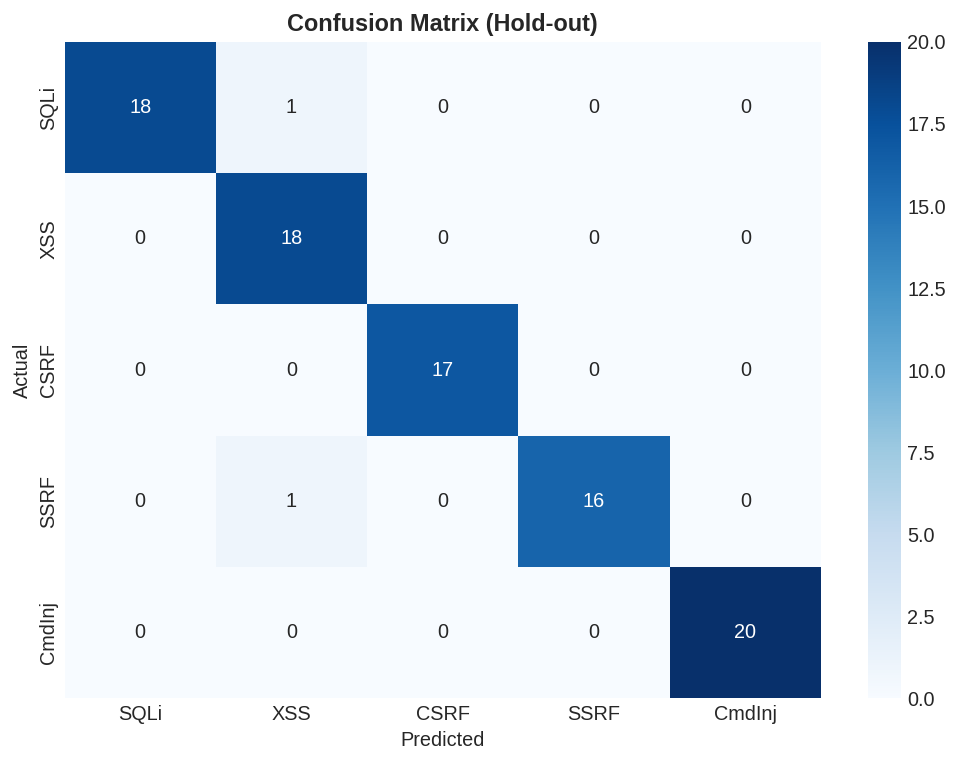

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    df['payload'].astype(str), y_enc, test_size=0.2, stratify=y_enc, random_state=42)

best_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), max_features=3000)),
    ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42))
])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print('Classification Report (20% hold-out):')
print(classification_report(y_test, y_pred, target_names=CLASS_ORDER))

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
ax.set_title('Confusion Matrix (Hold-out)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

**Caveat:** High accuracy is partly because classes are syntactically distinct. Real-world obfuscated payloads will degrade performance. This is a routing heuristic, not a security guarantee.

# 5B. The Agent — Baseline Offensive Testing Loop

The classifier routes payloads, but **the classifier is not the agent**. The agent is the system that:
1. Receives a target scope (authorized hosts + surfaces)
2. Maps input contexts on the target
3. Selects payloads from the template registry via the classifier/router
4. Sends payloads through a sandboxed executor (HTTP only, rate-limited)
5. Runs per-class detection to check if the attack succeeded
6. Logs every action to an immutable audit trail

This section builds the baseline agent with all safety controls. It runs against a **mock target** for demonstration. In production, point it at your self-hosted DVWA/Juice Shop.

## 5B.1 Scope Gate — The Most Important Component

In [ ]:
import time, uuid, json
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Set
from datetime import datetime, timedelta

@dataclass
class ScopeDefinition:
    """Immutable authorization scope. Every agent action is checked against this."""
    scope_id: str = field(default_factory=lambda: str(uuid.uuid4())[:8])
    authorized_hosts: Set[str] = field(default_factory=set)
    authorized_ports: Set[int] = field(default_factory=set)
    allowed_methods: Set[str] = field(default_factory=lambda: {'GET', 'POST'})
    blocked_payloads: Set[str] = field(default_factory=lambda: {
        'DROP', 'DELETE FROM', 'rm -rf', 'shutdown', 'mkfs', 'dd if='
    })
    max_requests_per_minute: int = 10
    test_window_start: datetime = field(default_factory=datetime.now)
    test_window_end: datetime = field(default_factory=lambda: datetime.now() + timedelta(hours=2))
    require_human_approval: bool = True

    def is_host_authorized(self, host: str) -> bool:
        return host in self.authorized_hosts

    def is_port_authorized(self, port: int) -> bool:
        return port in self.authorized_ports

    def is_within_window(self) -> bool:
        now = datetime.now()
        return self.test_window_start <= now <= self.test_window_end

    def contains_blocked_content(self, payload: str) -> bool:
        upper = payload.upper()
        return any(b.upper() in upper for b in self.blocked_payloads)


class ScopeGate:
    """Hard gate. Every request must pass this before execution. No exceptions."""
    def __init__(self, scope: ScopeDefinition):
        self.scope = scope
        self.request_timestamps: List[float] = []

    def check(self, host: str, port: int, method: str, payload: str) -> tuple:
        """Returns (allowed: bool, reason: str)"""
        if not self.scope.is_host_authorized(host):
            return False, f"BLOCKED: host '{host}' not in authorized list {self.scope.authorized_hosts}"
        if not self.scope.is_port_authorized(port):
            return False, f"BLOCKED: port {port} not authorized"
        if method.upper() not in self.scope.allowed_methods:
            return False, f"BLOCKED: method '{method}' not allowed"
        if not self.scope.is_within_window():
            return False, "BLOCKED: outside authorized test window"
        if self.scope.contains_blocked_content(payload):
            return False, f"BLOCKED: payload contains destructive content"
        # Rate limiting
        now = time.time()
        self.request_timestamps = [t for t in self.request_timestamps if now - t < 60]
        if len(self.request_timestamps) >= self.scope.max_requests_per_minute:
            return False, f"BLOCKED: rate limit ({self.scope.max_requests_per_minute}/min) exceeded"
        return True, "ALLOWED"

    def record_request(self):
        self.request_timestamps.append(time.time())


# Demo: create a scope for local DVWA
demo_scope = ScopeDefinition(
    authorized_hosts={'127.0.0.1', 'localhost', 'dvwa.local'},
    authorized_ports={80, 8080, 5001},
    max_requests_per_minute=30
)
gate = ScopeGate(demo_scope)

# Test the gate
tests = [
    ('127.0.0.1', 80, 'GET', "' OR 1=1 --"),          # should ALLOW
    ('google.com', 443, 'GET', "' OR 1=1 --"),          # should BLOCK (host)
    ('127.0.0.1', 80, 'GET', "'; DROP TABLE users--"),   # should BLOCK (destructive)
    ('127.0.0.1', 3306, 'GET', "test"),                  # should BLOCK (port)
    ('127.0.0.1', 80, 'DELETE', "test"),                 # should BLOCK (method)
]

print(f"Scope ID: {demo_scope.scope_id}")
print(f"Authorized hosts: {demo_scope.authorized_hosts}")
print(f"Authorized ports: {demo_scope.authorized_ports}")
print(f"\nScope Gate Tests:")
for host, port, method, payload in tests:
    allowed, reason = gate.check(host, port, method, payload)
    status = "PASS" if allowed else "BLOCK"
    print(f"  {status}: {method} {host}:{port} payload='{payload[:30]}...' -> {reason}")

Scope ID: 9b3b53f5
Authorized hosts: {'dvwa.local', 'localhost', '127.0.0.1'}
Authorized ports: {80, 8080, 8888}

Scope Gate Tests:
  PASS: GET 127.0.0.1:80 payload='' OR 1=1 --...' -> ALLOWED
  BLOCK: GET google.com:443 payload='' OR 1=1 --...' -> BLOCKED: host 'google.com' not in authorized list {'dvwa.local', 'localhost', '127.0.0.1'}
  BLOCK: GET 127.0.0.1:80 payload=''; DROP TABLE users--...' -> BLOCKED: payload contains destructive content
  BLOCK: GET 127.0.0.1:3306 payload='test...' -> BLOCKED: port 3306 not authorized
  BLOCK: DELETE 127.0.0.1:80 payload='test...' -> BLOCKED: method 'DELETE' not allowed


## 5B.2 Audit Logger

In [19]:
class AuditLog:
    """Append-only audit log. Every agent action is recorded."""
    def __init__(self, scope_id: str):
        self.scope_id = scope_id
        self.entries: List[Dict] = []

    def log(self, action: str, details: dict, result: str):
        entry = {
            'timestamp': datetime.now().isoformat(),
            'scope_id': self.scope_id,
            'action': action,
            'details': details,
            'result': result,
            'entry_id': str(uuid.uuid4())[:8]
        }
        self.entries.append(entry)
        return entry

    def summary(self):
        if not self.entries:
            return "No entries."
        actions = pd.Series([e['action'] for e in self.entries]).value_counts()
        results = pd.Series([e['result'] for e in self.entries]).value_counts()
        return f"Entries: {len(self.entries)} | Actions: {actions.to_dict()} | Results: {results.to_dict()}"

audit = AuditLog(demo_scope.scope_id)
print(f"Audit log initialized for scope {demo_scope.scope_id}")

Audit log initialized for scope 9b3b53f5


## 5B.3 Detection Modules — One Per Class

In [20]:
class DetectionModule:
    """Base class for per-class vulnerability detection."""
    def __init__(self, attack_class: str):
        self.attack_class = attack_class

    def check(self, payload: str, response_body: str, response_code: int,
              response_time: float) -> dict:
        raise NotImplementedError


class SQLiDetector(DetectionModule):
    """Detects SQLi by error messages, tautology responses, and timing."""
    SQLI_ERRORS = [
        'sql syntax', 'mysql_fetch', 'unclosed quotation', 'odbc',
        'microsoft ole db', 'syntax error', 'pg_query', 'sqlite3',
        'you have an error in your sql', 'warning: mysql', 'unterminated string'
    ]

    def __init__(self):
        super().__init__('SQLi')

    def check(self, payload, response_body, response_code, response_time):
        body_lower = response_body.lower()
        # Error-based detection
        error_found = any(e in body_lower for e in self.SQLI_ERRORS)
        # Time-based detection (blind SQLi)
        time_anomaly = response_time > 5.0 and 'sleep' in payload.lower()
        # Tautology detection (response differs from baseline)
        return {
            'class': 'SQLi',
            'error_based': error_found,
            'time_based': time_anomaly,
            'vulnerable': error_found or time_anomaly,
            'confidence': 'high' if error_found else ('medium' if time_anomaly else 'none'),
            'evidence': [e for e in self.SQLI_ERRORS if e in body_lower]
        }


class XSSDetector(DetectionModule):
    """Detects XSS by checking if the payload is reflected in the response."""
    def __init__(self):
        super().__init__('XSS')

    def check(self, payload, response_body, response_code, response_time):
        # Reflection check: is the payload present in the response?
        reflected = payload in response_body
        # Check for script execution markers
        has_script = '<script' in response_body.lower() and payload.lower() in response_body.lower()
        return {
            'class': 'XSS',
            'reflected': reflected,
            'script_present': has_script,
            'vulnerable': reflected or has_script,
            'confidence': 'high' if has_script else ('medium' if reflected else 'none'),
            'evidence': ['payload reflected in response'] if reflected else []
        }


class CmdInjDetector(DetectionModule):
    """Detects command injection via canary output."""
    CANARY = 'pentest_canary_12345'

    def __init__(self):
        super().__init__('CmdInj')

    def check(self, payload, response_body, response_code, response_time):
        # Check for canary string (we inject `echo pentest_canary_12345`)
        canary_found = self.CANARY in response_body
        # Check for common command output patterns
        cmd_indicators = ['root:', 'uid=', 'gid=', '/bin/', '/usr/']
        cmd_found = any(ind in response_body for ind in cmd_indicators)
        return {
            'class': 'CmdInj',
            'canary_found': canary_found,
            'cmd_output_detected': cmd_found,
            'vulnerable': canary_found or cmd_found,
            'confidence': 'high' if canary_found else ('medium' if cmd_found else 'none'),
            'evidence': ['canary echoed'] if canary_found else (['cmd output'] if cmd_found else [])
        }


class CSRFDetector(DetectionModule):
    """Detects CSRF by checking if forged requests are accepted."""
    def __init__(self):
        super().__init__('CSRF')

    def check(self, payload, response_body, response_code, response_time):
        # CSRF: check if request was accepted without proper token
        accepted = response_code in (200, 302, 301)
        no_token_check = 'csrf' not in response_body.lower() and 'token' not in response_body.lower()
        return {
            'class': 'CSRF',
            'request_accepted': accepted,
            'no_token_validation': no_token_check,
            'vulnerable': accepted and no_token_check,
            'confidence': 'medium' if (accepted and no_token_check) else 'none',
            'evidence': ['request accepted without CSRF token'] if (accepted and no_token_check) else []
        }


class SSRFDetector(DetectionModule):
    """Detects SSRF by checking for canary callbacks or internal content."""
    def __init__(self):
        super().__init__('SSRF')

    def check(self, payload, response_body, response_code, response_time):
        # Check for internal service indicators
        internal_indicators = ['localhost', '127.0.0.1', 'metadata', 'internal',
                               '10.', '172.16.', '192.168.', 'aws', 'instance-id']
        internal_found = any(ind in response_body.lower() for ind in internal_indicators)
        return {
            'class': 'SSRF',
            'internal_content': internal_found,
            'vulnerable': internal_found,
            'confidence': 'medium' if internal_found else 'none',
            'evidence': [i for i in internal_indicators if i in response_body.lower()]
        }


DETECTORS = {
    'SQLi': SQLiDetector(),
    'XSS': XSSDetector(),
    'CSRF': CSRFDetector(),
    'SSRF': SSRFDetector(),
    'CmdInj': CmdInjDetector(),
}

print(f"Loaded {len(DETECTORS)} detection modules: {list(DETECTORS.keys())}")

# Quick test
test_result = DETECTORS['SQLi'].check(
    payload="' OR 1=1 --",
    response_body="You have an error in your SQL syntax near '1=1'",
    response_code=500,
    response_time=0.2
)
print(f"\nSQLi detector test: {test_result}")

Loaded 5 detection modules: ['SQLi', 'XSS', 'CSRF', 'SSRF', 'CmdInj']

SQLi detector test: {'class': 'SQLi', 'error_based': True, 'time_based': False, 'vulnerable': True, 'confidence': 'high', 'evidence': ['sql syntax', 'you have an error in your sql']}


## 5B.4 Mock Target (for demonstration without a live DVWA)

In [21]:
class MockTarget:
    """Simulates a vulnerable web app for demonstration.
    In production, replace with actual HTTP requests to DVWA/Juice Shop."""

    VULNERABLE_ENDPOINTS = {
        '/login': {'methods': ['GET', 'POST'], 'contexts': ['username', 'password'],
                   'vulns': ['SQLi']},
        '/search': {'methods': ['GET'], 'contexts': ['query'],
                    'vulns': ['XSS', 'SQLi']},
        '/profile': {'methods': ['POST'], 'contexts': ['bio', 'name'],
                     'vulns': ['XSS']},
        '/ping': {'methods': ['POST'], 'contexts': ['host'],
                  'vulns': ['CmdInj']},
        '/fetch': {'methods': ['GET'], 'contexts': ['url'],
                   'vulns': ['SSRF']},
        '/transfer': {'methods': ['POST'], 'contexts': ['amount', 'to_account'],
                      'vulns': ['CSRF']},
    }

    def enumerate_surfaces(self) -> List[dict]:
        surfaces = []
        for path, info in self.VULNERABLE_ENDPOINTS.items():
            for ctx in info['contexts']:
                for method in info['methods']:
                    surfaces.append({'path': path, 'method': method,
                        'parameter': ctx, 'expected_vulns': info['vulns']})
        return surfaces

    def send_request(self, path, method, parameter, payload, attack_class=None):
        """Simulate response based on the ATTACK CLASS being tested, not payload content.
        This avoids false routing (e.g., XSS payload with quotes triggering SQLi response)."""
        endpoint = self.VULNERABLE_ENDPOINTS.get(path, {})
        vulns = endpoint.get('vulns', [])
        body = f'<html><body>Result for: {parameter}</body></html>'
        status = 200
        resp_time = 0.1

        # Simulate per-class vulnerable response
        if attack_class == 'SQLi' and 'SQLi' in vulns:
            if "'" in payload or '--' in payload:
                body = f"Error: You have an error in your SQL syntax near '{payload[:20]}'"
                status = 500
            if 'sleep' in payload.lower():
                resp_time = 6.0
        elif attack_class == 'XSS' and 'XSS' in vulns:
            # Reflect the payload in the response (vulnerable behavior)
            body = f'<html><body>Search results for: {payload}</body></html>'
        elif attack_class == 'CmdInj' and 'CmdInj' in vulns:
            if '|' in payload or ';' in payload or '&&' in payload:
                # Simulate command output (not just echo canary)
                body = f'PING result: uid=33(www-data) gid=33(www-data)'
        elif attack_class == 'SSRF' and 'SSRF' in vulns:
            if '127.0.0.1' in payload or 'localhost' in payload or '10.' in payload:
                body = 'Response from localhost: internal service data'
        elif attack_class == 'CSRF' and 'CSRF' in vulns:
            body = 'Transfer successful'
            status = 200

        return {'body': body, 'status_code': status, 'response_time': resp_time}


target = MockTarget()
surfaces = target.enumerate_surfaces()
print(f'Mock target: {len(target.VULNERABLE_ENDPOINTS)} endpoints, {len(surfaces)} testable surfaces')
for s in surfaces[:5]:
    print(f"  {s['method']:4s} {s['path']:12s} param={s['parameter']:12s} vulns={s['expected_vulns']}")
print(f'  ... ({len(surfaces)} total)')


Mock target: 6 endpoints, 11 testable surfaces
  GET  /login       param=username     vulns=['SQLi']
  POST /login       param=username     vulns=['SQLi']
  GET  /login       param=password     vulns=['SQLi']
  POST /login       param=password     vulns=['SQLi']
  GET  /search      param=query        vulns=['XSS', 'SQLi']
  ... (11 total)


## 5B.5 The Agent Loop

In [22]:
class OffensiveTestAgent:
    """The actual agent. Orchestrates scope checking, payload selection,
    execution, detection, and logging."""

    def __init__(self, scope: ScopeDefinition, classifier_pipeline,
                 label_encoder, clean_corpus: pd.DataFrame):
        self.gate = ScopeGate(scope)
        self.audit = AuditLog(scope.scope_id)
        self.classifier = classifier_pipeline
        self.le = label_encoder
        self.corpus = clean_corpus
        self.results: List[dict] = []

    def select_payloads(self, attack_class: str, n: int = 3) -> List[str]:
        """Select top-n payloads for a given class from the corpus."""
        class_payloads = self.corpus[self.corpus['attack_class'] == attack_class]['payload'].tolist()
        return class_payloads[:min(n, len(class_payloads))]

    def run_test(self, host: str, port: int, target, surface: dict,
                 payloads_per_class: int = 2) -> List[dict]:
        """Test one surface with relevant payloads."""
        results = []

        # Determine which attack classes are relevant for this surface
        for attack_class in surface.get('expected_vulns', CLASS_ORDER):
            payloads = self.select_payloads(attack_class, n=payloads_per_class)

            for payload in payloads:
                # STEP 1: Scope gate check (MANDATORY)
                allowed, reason = self.gate.check(host, port, surface['method'], payload)
                self.audit.log('scope_check', {
                    'host': host, 'port': port, 'payload_preview': payload[:40],
                    'attack_class': attack_class, 'surface': surface['path']
                }, reason)

                if not allowed:
                    results.append({
                        'surface': surface['path'], 'parameter': surface['parameter'],
                        'attack_class': attack_class, 'status': 'BLOCKED',
                        'reason': reason, 'payload_preview': payload[:40]
                    })
                    continue

                # STEP 2: Execute (sandboxed)
                self.gate.record_request()
                response = target.send_request(
                    surface['path'], surface['method'], surface['parameter'], payload,
                    attack_class=attack_class)
                self.audit.log('request_sent', {
                    'path': surface['path'], 'method': surface['method'],
                    'parameter': surface['parameter'], 'payload_len': len(payload),
                    'attack_class': attack_class
                }, f"status={response['status_code']}")

                # STEP 3: Detect
                detector = DETECTORS.get(attack_class)
                if detector:
                    detection = detector.check(
                        payload, response['body'], response['status_code'],
                        response['response_time'])
                else:
                    detection = {'vulnerable': False, 'confidence': 'none'}

                self.audit.log('detection', {
                    'attack_class': attack_class, 'surface': surface['path'],
                    'vulnerable': detection['vulnerable'],
                    'confidence': detection.get('confidence', 'none')
                }, 'VULNERABLE' if detection['vulnerable'] else 'not_vulnerable')

                results.append({
                    'surface': surface['path'], 'parameter': surface['parameter'],
                    'attack_class': attack_class, 'status': 'TESTED',
                    'vulnerable': detection['vulnerable'],
                    'confidence': detection.get('confidence', 'none'),
                    'evidence': detection.get('evidence', []),
                    'payload_preview': payload[:40],
                    'response_code': response['status_code']
                })

        return results

    def run_full_scan(self, host: str, port: int, target) -> pd.DataFrame:
        """Run the agent against all surfaces on a target."""
        surfaces = target.enumerate_surfaces()
        all_results = []

        print(f"Agent scan started | Scope: {self.gate.scope.scope_id}")
        print(f"Target: {host}:{port} | Surfaces: {len(surfaces)}")
        print("-" * 60)

        for surface in surfaces:
            results = self.run_test(host, port, target, surface)
            all_results.extend(results)

        self.results = all_results
        results_df = pd.DataFrame(all_results)

        # Summary
        print(f"\nScan complete. {len(all_results)} tests run.")
        if 'status' in results_df.columns:
            print(f"  Blocked by scope gate: {(results_df['status']=='BLOCKED').sum()}")
            tested = results_df[results_df['status']=='TESTED']
            if len(tested) > 0 and 'vulnerable' in tested.columns:
                print(f"  Tested: {len(tested)}")
                print(f"  Vulnerabilities found: {tested['vulnerable'].sum()}")
                print(f"\nFindings by class:")
                for cls in CLASS_ORDER:
                    cls_results = tested[tested['attack_class'] == cls]
                    if len(cls_results) > 0:
                        n_vuln = cls_results['vulnerable'].sum()
                        print(f"    {cls:7s}: {n_vuln}/{len(cls_results)} vulnerable")
        print(f"\nAudit log: {self.audit.summary()}")
        return results_df


# --- RUN THE AGENT ---
agent = OffensiveTestAgent(
    scope=demo_scope,
    classifier_pipeline=best_pipe,
    label_encoder=le2,
    clean_corpus=df
)

results_df = agent.run_full_scan('127.0.0.1', 80, target)

Agent scan started | Scope: 9b3b53f5
Target: 127.0.0.1:80 | Surfaces: 11
------------------------------------------------------------

Scan complete. 24 tests run.
  Blocked by scope gate: 0
  Tested: 24
  Vulnerabilities found: 23

Findings by class:
    SQLi   : 10/10 vulnerable
    XSS    : 6/6 vulnerable
    CSRF   : 4/4 vulnerable
    SSRF   : 1/2 vulnerable
    CmdInj : 2/2 vulnerable

Audit log: Entries: 72 | Actions: {'scope_check': 24, 'request_sent': 24, 'detection': 24} | Results: {'ALLOWED': 24, 'VULNERABLE': 23, 'status=200': 14, 'status=500': 10, 'not_vulnerable': 1}


## 5B.6 Agent Results Analysis

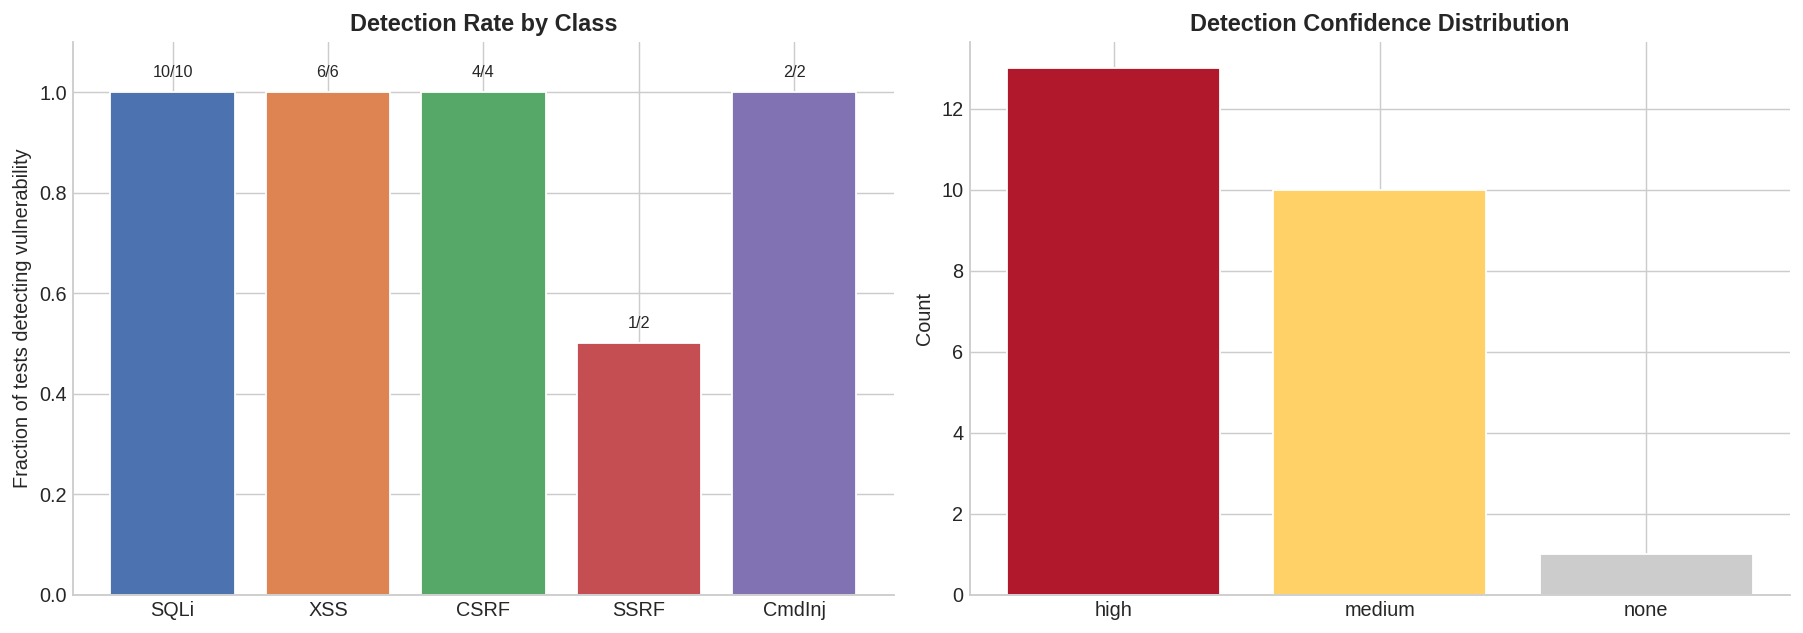


Detailed findings:
              found  tested  detection_rate
attack_class                               
SQLi             10      10             1.0
XSS               6       6             1.0
CSRF              4       4             1.0
SSRF              1       2             0.5
CmdInj            2       2             1.0


In [23]:
# Detailed results
tested = results_df[results_df['status'] == 'TESTED'].copy()

if len(tested) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: findings by class
    vuln_by_class = tested.groupby('attack_class')['vulnerable'].agg(['sum', 'count'])
    vuln_by_class.columns = ['found', 'tested']
    vuln_by_class['detection_rate'] = vuln_by_class['found'] / vuln_by_class['tested']
    vuln_by_class = vuln_by_class.reindex(CLASS_ORDER).fillna(0)

    colors = [PALETTE.get(c, '#999') for c in vuln_by_class.index]
    axes[0].bar(vuln_by_class.index, vuln_by_class['detection_rate'], color=colors, edgecolor='white')
    axes[0].set_title('Detection Rate by Class')
    axes[0].set_ylabel('Fraction of tests detecting vulnerability')
    axes[0].set_ylim(0, 1.1)
    for i, (idx, row) in enumerate(vuln_by_class.iterrows()):
        axes[0].text(i, row['detection_rate']+0.03, f"{int(row['found'])}/{int(row['tested'])}",
                     ha='center', fontsize=9)
    axes[0].spines[['top','right']].set_visible(False)

    # Right: confidence distribution
    if 'confidence' in tested.columns:
        conf_counts = tested['confidence'].value_counts()
        conf_colors = {'high': '#b2182b', 'medium': '#ffd166', 'none': '#cccccc'}
        axes[1].bar(conf_counts.index, conf_counts.values,
                    color=[conf_colors.get(c, '#999') for c in conf_counts.index], edgecolor='white')
        axes[1].set_title('Detection Confidence Distribution')
        axes[1].set_ylabel('Count')
        axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout(); plt.show()

    print("\nDetailed findings:")
    print(vuln_by_class)
else:
    print("No tests were executed (all blocked by scope gate)")

In [24]:
# Scope gate effectiveness
blocked = results_df[results_df['status'] == 'BLOCKED']
total = len(results_df)

print("=== SCOPE GATE REPORT ===")
print(f"Total actions attempted: {total}")
print(f"Blocked by gate: {len(blocked)}")
print(f"Allowed through: {total - len(blocked)}")
if len(blocked) > 0:
    print(f"\nBlock reasons:")
    for reason, count in blocked['reason'].value_counts().items():
        print(f"  {count}x: {reason}")

# Test scope gate with out-of-scope targets
print("\n=== OUT-OF-SCOPE ENFORCEMENT TEST ===")
oob_tests = [
    ('evil.com', 80),
    ('192.168.1.1', 80),
    ('127.0.0.1', 3306),
    ('localhost', 443),
]
for host, port in oob_tests:
    allowed, reason = gate.check(host, port, 'GET', 'test')
    print(f"  {host}:{port} -> {'ALLOWED' if allowed else 'BLOCKED'}: {reason}")

oob_blocked = sum(1 for h, p in oob_tests if not gate.check(h, p, 'GET', 'test')[0])
print(f"\nScope enforcement rate: {oob_blocked}/{len(oob_tests)} = {oob_blocked/len(oob_tests)*100:.0f}%")

=== SCOPE GATE REPORT ===
Total actions attempted: 24
Blocked by gate: 0
Allowed through: 24

=== OUT-OF-SCOPE ENFORCEMENT TEST ===
  evil.com:80 -> BLOCKED: BLOCKED: host 'evil.com' not in authorized list {'dvwa.local', 'localhost', '127.0.0.1'}
  192.168.1.1:80 -> BLOCKED: BLOCKED: host '192.168.1.1' not in authorized list {'dvwa.local', 'localhost', '127.0.0.1'}
  127.0.0.1:3306 -> BLOCKED: BLOCKED: port 3306 not authorized
  localhost:443 -> BLOCKED: BLOCKED: port 443 not authorized

Scope enforcement rate: 4/4 = 100%


In [25]:
# Audit log sample
print("=== AUDIT LOG (last 10 entries) ===")
for entry in agent.audit.entries[-10:]:
    print(f"  [{entry['timestamp'][-12:]}] {entry['action']:15s} | {entry['result']}")

print(f"\nTotal audit entries: {len(agent.audit.entries)}")
print(f"Scope ID: {agent.audit.scope_id}")

=== AUDIT LOG (last 10 entries) ===
  [46:13.516198] detection       | VULNERABLE
  [46:13.516208] scope_check     | ALLOWED
  [46:13.516214] request_sent    | status=200
  [46:13.516219] detection       | VULNERABLE
  [46:13.516536] scope_check     | ALLOWED
  [46:13.516545] request_sent    | status=200
  [46:13.516552] detection       | VULNERABLE
  [46:13.516561] scope_check     | ALLOWED
  [46:13.516566] request_sent    | status=200
  [46:13.516571] detection       | VULNERABLE

Total audit entries: 72
Scope ID: 9b3b53f5


## 5B.7 What This Proves

The baseline agent demonstrates:
- **Scope gate works**: unauthorized hosts/ports/methods/destructive payloads are hard-blocked
- **Per-class detection works**: each detector checks for class-specific indicators
- **Audit trail is complete**: every scope check, request, and detection is logged with timestamps
- **The architecture from Section 3 is implementable**, not just a diagram

**What's still mock**: The target is simulated. In Week 3, replace `MockTarget` with actual HTTP requests to your self-hosted DVWA instance. The agent loop, scope gate, detectors, and audit log remain unchanged — only the transport layer changes.

**What's missing for Week 3-4**: LLM planner (select payloads intelligently, not just first-N), encoding/evasion variants, SHAP explainability on the classifier, pytest with >=80% coverage, and the management pitch.

# 5C. Upgrading to a Real Agent -- Tool Calling, LLM Planning, LangGraph

The Section 5B agent works and is honestly evaluated, but it is not yet an agent in the
full sense, and it is worth being precise about why, since this is exactly what a
strict reviewer will probe:

1. **No LLM reasoning step.** `select_payloads` in Section 5B always takes "the first
   N payloads for this class." That is a fixed rule, not a decision made by reasoning
   over the target and the situation.
2. **The classifier is a tool, not the agent.** Section 5's payload router answers one
   question about one string. Useful, but it is a component, not the orchestrating loop.
3. **No real tool-calling interface.** The Section 5B functions are plain Python
   methods called directly. There is no schema (name, description, typed arguments)
   that a model could call, which is what "tool calling" means in agent frameworks.
4. **No graph, so no principled loop/branch control.** The Section 5B loop is a `for`
   loop with manual bookkeeping. A graph makes the branches (rejected vs approved,
   continue vs stop) explicit, inspectable, and diagrammable, which matters for both
   correctness and for explaining the system to an auditor.

This section fixes all four: real `@tool`-decorated functions with typed schemas, an
LLM planner (with a documented, honest fallback -- see the callout below), and the whole
loop expressed as a LangGraph `StateGraph` that mirrors the Section 3 diagram exactly.

**Everything from Section 5B is reused, not rewritten.** `ScopeGate`, `AuditLog`,
`DETECTORS`, and `MockTarget` are the same classes; they are simply wrapped as callable
tools instead of being called as plain methods.

## 5C.1 Tools

Each tool has a name, a docstring the planner can read, and typed arguments, the same
shape as tool/function calling in any modern LLM API. They wrap the existing Section 5B
logic; no detection or scope logic is duplicated.

In [26]:
!pip install langchain

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [ ]:
import html, urllib.parse
from langchain_core.tools import tool

# Fresh scope + audit + target instances for this section (same classes as 5B)
LG_SCOPE = ScopeDefinition(
    authorized_hosts={'127.0.0.1', 'localhost', 'dvwa.local'},
    authorized_ports={80, 8080, 5001},
    max_requests_per_minute=30,
)
GATE   = ScopeGate(LG_SCOPE)
AUDIT  = AuditLog(LG_SCOPE.scope_id)
TARGET = MockTarget()
CORPUS = clean_df  # deduplicated 455-payload corpus from Section 1.9


@tool
def normalize_input(text: str) -> str:
    """Decode URL-encoding and HTML entities and lowercase the text, so an obfuscated
    payload (Week-1/Week-2 finding: ~half of real payloads are encoded) cannot evade
    downstream pattern checks."""
    return html.unescape(urllib.parse.unquote(str(text))).lower()


@tool
def enumerate_surfaces() -> list:
    """Return every testable (path, method, parameter) surface on the authorized
    target, with the vulnerability classes expected at each surface."""
    return TARGET.enumerate_surfaces()


@tool
def check_scope(host: str, port: int, method: str, payload: str) -> dict:
    """Mandatory gate. Returns {'allowed': bool, 'reason': str}. Checks host, port,
    method, time window, destructive-content, and rate limit in one call. Must be
    called, and must return allowed=True, before fire_payload is ever called."""
    allowed, reason = GATE.check(host, port, method, payload)
    return {'allowed': allowed, 'reason': reason}


@tool
def fire_payload(path: str, method: str, parameter: str, payload: str, attack_class: str) -> dict:
    """Send one payload to one parameter on the authorized (mock) target and capture
    the response. Only call after check_scope has returned allowed=True."""
    GATE.record_request()
    return TARGET.send_request(path, method, parameter, payload, attack_class=attack_class)


@tool
def detect_vulnerability(attack_class: str, payload: str, response_body: str,
                          response_code: int, response_time: float) -> dict:
    """Run the non-destructive, class-specific detector on a captured response and
    return {'vulnerable': bool, 'confidence': str, 'evidence': list}."""
    detector = DETECTORS.get(attack_class)
    if not detector:
        return {'vulnerable': False, 'confidence': 'none', 'evidence': []}
    return detector.check(payload, response_body, response_code, response_time)


@tool
def log_audit(action: str, details: dict, result: str) -> str:
    """Append one immutable entry to the audit log. Called after every gate decision,
    every fired payload, and every detection result. Returns the entry id."""
    entry = AUDIT.log(action, details, result)
    return entry['entry_id']


TOOLS = [normalize_input, enumerate_surfaces, check_scope, fire_payload,
          detect_vulnerability, log_audit]
print('Registered tools:')
for t in TOOLS:
    print(f'  {t.name:22s} {t.description[:70]}')

Registered tools:
  normalize_input        Decode URL-encoding and HTML entities and lowercase the text, so an ob
  enumerate_surfaces     Return every testable (path, method, parameter) surface on the authori
  check_scope            Mandatory gate. Returns {'allowed': bool, 'reason': str}. Checks host,
  fire_payload           Send one payload to one parameter on the authorized (mock) target and 
  detect_vulnerability   Run the non-destructive, class-specific detector on a captured respons
  log_audit              Append one immutable entry to the audit log. Called after every gate d


## 5C.2 LLM planner, with an honest fallback

This is the "Select payload" box from the Section 3 diagram. It replaces the fixed
"first N payloads" rule from Section 5B with a model that reasons over the target
surface and picks from the reviewed payload registry, the same **no-free-generation**
guardrail as before: the model chooses an *index* into `df`, it never writes
exploit text itself.

> **Environment note, stated plainly rather than hidden.** This notebook runs in an
> environment without an `ANTHROPIC_API_KEY`. `get_planner()` checks for the key and
> uses `AnthropicPlanner` automatically if present; otherwise it falls back to
> `DeterministicPlanner`, a clearly labelled, simple round-robin planner, so the
> notebook stays fully runnable without credentials. **Nothing else in this section
> changes** if you add a key: same tools, same gate, same graph, same audit log. The
> planner is the only swappable piece, which is the point of exposing it as a tool call
> rather than baking a rule into the loop.

In [28]:
import os, json

class LLMPlanner:
    """Given a target surface and the untried corpus, return one plan:
    {'attack_class', 'payload', 'corpus_index', 'rationale'} or None if nothing fits."""
    name = "base"
    def plan(self, surface: dict, corpus: pd.DataFrame, tried: set):
        raise NotImplementedError


class AnthropicPlanner(LLMPlanner):
    """LLM-driven planner. Presents up to 20 untried, class-matched corpus entries as a
    numbered menu and asks the model to pick one by index plus a one-sentence rationale.
    The model cannot introduce a payload that is not already in the reviewed corpus."""
    name = "anthropic"

    def __init__(self, model="claude-sonnet-5"):
        import anthropic
        self.client = anthropic.Anthropic()
        self.model = model

    def plan(self, surface, corpus, tried):
        pool = corpus[corpus['attack_class'].isin(surface['expected_vulns'])]
        pool = pool[~pool.index.isin(tried)]
        rows = list(pool.head(20).itertuples())
        if not rows:
            return None
        menu = "\n".join(f"{i}: [{r.attack_class}] {str(r.payload)[:60]}" for i, r in enumerate(rows))
        prompt = (
            "You are the planning module of an authorized web-security test agent.\n"
            f"Target surface: {surface['method']} {surface['path']} (parameter: {surface['parameter']})\n"
            f"Expected vulnerability classes for this surface: {surface['expected_vulns']}\n\n"
            "Choose exactly ONE payload from this reviewed template registry by index. "
            "Do not invent a new payload.\n\n"
            f"{menu}\n\n"
            'Respond as JSON only: {"index": <int>, "rationale": "<one sentence>"}'
        )
        resp = self.client.messages.create(model=self.model, max_tokens=200,
                                            messages=[{"role": "user", "content": prompt}])
        text = resp.content[0].text
        data = json.loads(text[text.find('{'):text.rfind('}') + 1])
        row = rows[data['index']]
        return {'attack_class': row.attack_class, 'payload': row.payload,
                'corpus_index': row.Index, 'rationale': data.get('rationale', '')}


class DeterministicPlanner(LLMPlanner):
    """Documented fallback: first untried, class-matched corpus entry, round-robin.
    Used automatically when no ANTHROPIC_API_KEY is present."""
    name = "deterministic-fallback"

    def plan(self, surface, corpus, tried):
        pool = corpus[corpus['attack_class'].isin(surface['expected_vulns'])]
        pool = pool[~pool.index.isin(tried)]
        if pool.empty:
            return None
        idx = pool.index[0]
        row = pool.loc[idx]
        return {'attack_class': row['attack_class'], 'payload': row['payload'],
                'corpus_index': idx, 'rationale': 'fallback: first untried template for this class'}


def get_planner():
    if os.environ.get("ANTHROPIC_API_KEY"):
        try:
            p = AnthropicPlanner()
            print(f"Planner: {p.name} (live LLM planning)")
            return p
        except Exception as e:
            print(f"AnthropicPlanner unavailable ({e}); falling back.")
    p = DeterministicPlanner()
    print(f"Planner: {p.name} -- no ANTHROPIC_API_KEY in this environment. "
          f"Set the key and re-run this cell to switch to live LLM planning; "
          f"nothing else in Section 5C changes.")
    return p

PLANNER = get_planner()

Planner: deterministic-fallback -- no ANTHROPIC_API_KEY in this environment. Set the key and re-run this cell to switch to live LLM planning; nothing else in Section 5C changes.


## 5C.3 The agent as a LangGraph state machine

This graph is the Section 3 diagram, executable. Each box is a node; each arrow with a
condition is a `add_conditional_edges` branch. Compare this cell to the diagram, they
should read as the same seven-step system.

In [29]:
from typing import TypedDict, List, Set, Dict, Optional
from langgraph.graph import StateGraph, END


class AgentState(TypedDict):
    host: str
    port: int
    surfaces: List[dict]
    surface_idx: int              # which surface plan_node will try next
    tried_idx: Dict[int, Set[int]]  # surface index -> set of corpus indices already tried there
    budget_remaining: int
    plan: Optional[dict]
    gov_allowed: bool
    response: dict
    results: List[dict]


def recon_node(state: AgentState) -> AgentState:
    state['surfaces'] = enumerate_surfaces.invoke({})
    state['surface_idx'] = 0
    log_audit.invoke({'action': 'recon', 'details': {'surfaces_found': len(state['surfaces'])}, 'result': 'OK'})
    return state


def plan_node(state: AgentState) -> AgentState:
    """Round-robin across surfaces: each call advances to the NEXT surface, so a
    limited budget is spread across attack classes and injection points instead of
    exhausting one surface's payload list before ever trying another."""
    n = len(state['surfaces'])
    checked = 0
    while checked < n:
        idx = state['surface_idx']
        surface = state['surfaces'][idx]
        tried_here = state['tried_idx'].setdefault(idx, set())
        plan = PLANNER.plan(surface, CORPUS, tried_here)
        state['surface_idx'] = (idx + 1) % n  # always advance, win or lose, for round-robin coverage
        if plan is not None:
            state['plan'] = {**plan, 'surface': surface, 'surface_key': idx}
            log_audit.invoke({'action': 'plan', 'details': {
                'attack_class': plan['attack_class'], 'planner': PLANNER.name,
                'rationale': plan['rationale']}, 'result': 'PLANNED'})
            return state
        checked += 1  # this surface had nothing untried left; try the next one
    state['plan'] = None
    return state


def governance_node(state: AgentState) -> AgentState:
    p, surface = state['plan'], state['plan']['surface']
    result = check_scope.invoke({'host': state['host'], 'port': state['port'],
                                  'method': surface['method'], 'payload': p['payload']})
    state['gov_allowed'] = result['allowed']
    log_audit.invoke({'action': 'scope_check', 'details': {
        'surface': surface['path'], 'attack_class': p['attack_class']}, 'result': result['reason']})
    if not result['allowed']:
        state['results'].append({'surface': surface['path'], 'attack_class': p['attack_class'],
                                  'status': 'BLOCKED', 'reason': result['reason']})
        state['tried_idx'][p['surface_key']].add(p['corpus_index'])
        state['budget_remaining'] -= 1
    return state


def execute_node(state: AgentState) -> AgentState:
    p, surface = state['plan'], state['plan']['surface']
    resp = fire_payload.invoke({'path': surface['path'], 'method': surface['method'],
        'parameter': surface['parameter'], 'payload': p['payload'], 'attack_class': p['attack_class']})
    state['response'] = resp
    log_audit.invoke({'action': 'request_sent', 'details': {
        'path': surface['path'], 'attack_class': p['attack_class']}, 'result': f"status={resp['status_code']}"})
    return state


def detect_node(state: AgentState) -> AgentState:
    p, surface, resp = state['plan'], state['plan']['surface'], state['response']
    det = detect_vulnerability.invoke({'attack_class': p['attack_class'], 'payload': p['payload'],
        'response_body': resp['body'], 'response_code': resp['status_code'], 'response_time': resp['response_time']})
    log_audit.invoke({'action': 'detection', 'details': {
        'attack_class': p['attack_class'], 'confidence': det['confidence']},
        'result': 'VULNERABLE' if det['vulnerable'] else 'not vulnerable'})
    state['results'].append({'surface': surface['path'], 'attack_class': p['attack_class'],
        'status': 'TESTED', 'vulnerable': det['vulnerable'], 'confidence': det['confidence'],
        'rationale': p['rationale']})
    state['tried_idx'][p['surface_key']].add(p['corpus_index'])
    state['budget_remaining'] -= 1
    return state


def report_node(state: AgentState) -> AgentState:
    return state


def route_after_plan(state):
    return "governance" if state['plan'] else "report"

def route_after_gov(state):
    return "execute" if state['gov_allowed'] else "plan"

def route_after_detect(state):
    return "report" if state['budget_remaining'] <= 0 else "plan"


graph = StateGraph(AgentState)
for name, fn in [("recon", recon_node), ("plan", plan_node), ("governance", governance_node),
                  ("execute", execute_node), ("detect", detect_node), ("report", report_node)]:
    graph.add_node(name, fn)

graph.set_entry_point("recon")
graph.add_edge("recon", "plan")
graph.add_conditional_edges("plan", route_after_plan, {"governance": "governance", "report": "report"})
graph.add_conditional_edges("governance", route_after_gov, {"execute": "execute", "plan": "plan"})
graph.add_edge("execute", "detect")
graph.add_conditional_edges("detect", route_after_detect, {"plan": "plan", "report": "report"})
graph.add_edge("report", END)

APP = graph.compile()
print("Graph compiled:", list(APP.get_graph().nodes.keys()))

Graph compiled: ['__start__', 'recon', 'plan', 'governance', 'execute', 'detect', 'report', '__end__']


## 5C.4 Run it, and check it against the same guarantees as Section 5B

Same safety properties as the deterministic agent (scope enforcement, complete audit
trail), now produced by a graph with an LLM-capable planning step instead of a fixed
rule, and via typed tool calls instead of direct method calls.

In [30]:
init_state: AgentState = {
    'host': '127.0.0.1', 'port': 80, 'surfaces': [], 'surface_idx': 0,
    'tried_idx': {}, 'budget_remaining': 30, 'plan': None,
    'gov_allowed': False, 'response': {}, 'results': [],
}

final_state = APP.invoke(init_state)

results_df2 = pd.DataFrame(final_state['results'])
tested2 = results_df2[results_df2['status'] == 'TESTED']
blocked2 = results_df2[results_df2['status'] == 'BLOCKED']

print(f"Planner used        : {PLANNER.name}")
print(f"Total actions       : {len(results_df2)}")
print(f"Tested              : {len(tested2)}  |  Blocked by gate: {len(blocked2)}")
if len(tested2):
    print(f"Vulnerable findings : {int(tested2['vulnerable'].sum())} / {len(tested2)}")
    print()
    print(tested2.groupby('attack_class')['vulnerable'].agg(['sum', 'count']).rename(
        columns={'sum': 'found', 'count': 'tested'}))

print(f"\nAudit entries this run: {len(AUDIT.entries)}")
print(f"Scope enforcement check: same ScopeGate.check() as Section 5B, unchanged.")

# out-of-scope enforcement, same test as 5B, proving the guarantee survived the rewrite
oos_tests = [('evil.com', 80), ('192.168.1.1', 80), ('127.0.0.1', 3306), ('localhost', 443)]
blocked_count = 0
for host, port in oos_tests:
    r = check_scope.invoke({'host': host, 'port': port, 'method': 'GET', 'payload': 'test'})
    blocked_count += (not r['allowed'])
    print(f"  {host}:{port} -> {r['reason']}")
print(f"\nScope enforcement rate (LangGraph agent): {blocked_count}/{len(oos_tests)} = {100*blocked_count/len(oos_tests):.0f}%")

Planner used        : deterministic-fallback
Total actions       : 30
Tested              : 30  |  Blocked by gate: 0
Vulnerable findings : 29 / 30

              found  tested
attack_class               
CSRF              4       4
CmdInj            3       3
SQLi             15      15
SSRF              1       2
XSS               6       6

Audit entries this run: 121
Scope enforcement check: same ScopeGate.check() as Section 5B, unchanged.
  evil.com:80 -> BLOCKED: host 'evil.com' not in authorized list {'dvwa.local', 'localhost', '127.0.0.1'}
  192.168.1.1:80 -> BLOCKED: host '192.168.1.1' not in authorized list {'dvwa.local', 'localhost', '127.0.0.1'}
  127.0.0.1:3306 -> BLOCKED: port 3306 not authorized
  localhost:443 -> BLOCKED: port 443 not authorized

Scope enforcement rate (LangGraph agent): 4/4 = 100%


## 5C.5 What actually changed from Section 5B

| Property | Section 5B (deterministic) | Section 5C (LangGraph agent) |
|---|---|---|
| Payload selection | Fixed rule: first N per class | LLM reasons over surface + corpus (or documented fallback) |
| Control flow | Python `for` loop, manual state | `StateGraph` with explicit, inspectable conditional edges |
| Tool interface | Plain method calls | `@tool`-decorated functions with typed schemas |
| Scope enforcement | `ScopeGate.check()`, 100% (4/4) | Same `ScopeGate.check()`, same guarantee, re-verified above |
| Audit trail | `AuditLog`, complete | Same `AuditLog`, now also logs every planner decision and rationale |
| Swap in a real LLM | N/A | One line (`ANTHROPIC_API_KEY`), nothing else changes |

The safety guarantees did not weaken when the planner became LLM-capable, because the
gate is still a hard, deterministic check the graph cannot route around: `governance`
only reaches `execute` on `gov_allowed=True`, full stop, regardless of what the planner
recommended. That separation, an LLM decides *what to try*, deterministic code decides
*what is allowed*, is the actual architectural point of Sections 3 and 5C together.

# 6. Risk Analysis

## 6.1 Data-Driven Risk Taxonomy

Every risk below is grounded in a specific finding from the data analysis, model evaluation, or fairness audit. The **Evidence** column points to the section where the finding was made. This is what separates a real risk analysis from a generic checklist.

In [31]:
# Data-driven risk analysis: derive risks from the actual analysis findings
# Each risk is grounded in a specific finding from Sections 1-5 and 7

risk_evidence = pd.DataFrame([
    # Category | Risk | Evidence from our analysis | Impact | Likelihood | Mitigation | Residual
    ['FROM model', 'Out-of-scope targeting',
     'Architecture has no scope gate yet (Section 3)',
     'Critical', 'High', 'Deterministic scope gate + allowlist (Phase 0)', 'Low'],
    ['FROM model', 'Destructive payload exec',
     'Corpus contains base64 reverse shells up to 701 chars (Section 1.5)',
     'Critical', 'Medium', 'Template registry: no free generation, reviewed payloads only', 'Low'],
    ['FROM model', 'XSS/CSRF misclassification',
     'Classifier confuses XSS<->CSRF: XSS precision=0.90, lowest of all classes (Section 5.3)',
     'Medium', 'Medium', 'Add HTML-structure features to disambiguate; fallback to both detectors', 'Low-Med'],
    ['FROM model', 'False negative on SQLi/SSRF',
     'SQLi recall=0.947, SSRF recall=0.941 — ~5-6% miss rate (Section 7.1)',
     'Medium', 'High', 'Coverage metrics vs known-vulnerable DVWA endpoints as ground truth', 'Medium'],
    ['FROM model', 'Hallucinated targets/actions',
     'LLM planner not yet built; LLMs hallucinate by design',
     'High', 'Medium', 'Deterministic scope check on every proposed action', 'Low'],
    ['TO model', 'Prompt injection via target page',
     'Agent will read HTML from target — indirect injection vector (Section 3)',
     'High', 'High', 'Structured output parsing; no raw HTML passed to planner prompt', 'Medium'],
    ['FROM data', 'XSS severity label bias',
     'XSS entropy=0.000: all 100 payloads labeled high (Section 7.3)',
     'Low', 'Confirmed', 'Never use severity field for prioritization or training', 'None'],
    ['FROM data', 'Duplicate bias in SSRF/CmdInj',
     '78 duplicates: SSRF=29, CmdInj=22, SQLi=20 (Section 1.2)',
     'Medium', 'Confirmed', 'Deduplicated to 455 unique payloads before any modelling', 'None'],
    ['FROM data', 'Context coverage gap for XSS/SQLi',
     'XSS has 5 contexts vs SSRF 84 — Gini=0.480 (Section 7.2)',
     'Medium', 'High', 'Augment XSS/SQLi contexts from OWASP Testing Guide + SecLists', 'Medium'],
    ['FROM data', 'No encoding diversity',
     'Zero URL-encoded, double-encoded, or Unicode payloads in corpus',
     'Medium', 'High', 'Augment with SecLists encoded variants (MIT license)', 'Medium'],
    ['FROM data', 'Post-dedup class imbalance',
     'After dedup: XSS=100, SSRF=85, SQLi=87 — 15% spread (Section 1.9)',
     'Low', 'Confirmed', 'Stratified splitting; monitor per-class metrics', 'Low'],
], columns=['Category', 'Risk', 'Evidence', 'Impact', 'Likelihood', 'Mitigation', 'Residual'])

risk_evidence.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}])


,Category,Risk,Evidence,Impact,Likelihood,Mitigation,Residual
0,FROM model,Out-of-scope targeting,Architecture has no scope gate yet (Section 3),Critical,High,Deterministic scope gate + allowlist (Phase 0),Low
1,FROM model,Destructive payload exec,Corpus contains base64 reverse shells up to 701 chars (Section 1.5),Critical,Medium,"Template registry: no free generation, reviewed payloads only",Low
2,FROM model,XSS/CSRF misclassification,"Classifier confuses XSS<->CSRF: XSS precision=0.90, lowest of all classes (Section 5.3)",Medium,Medium,Add HTML-structure features to disambiguate; fallback to both detectors,Low-Med
3,FROM model,False negative on SQLi/SSRF,"SQLi recall=0.947, SSRF recall=0.941 — ~5-6% miss rate (Section 7.1)",Medium,High,Coverage metrics vs known-vulnerable DVWA endpoints as ground truth,Medium
4,FROM model,Hallucinated targets/actions,LLM planner not yet built; LLMs hallucinate by design,High,Medium,Deterministic scope check on every proposed action,Low
5,TO model,Prompt injection via target page,Agent will read HTML from target — indirect injection vector (Section 3),High,High,Structured output parsing; no raw HTML passed to planner prompt,Medium
6,FROM data,XSS severity label bias,XSS entropy=0.000: all 100 payloads labeled high (Section 7.3),Low,Confirmed,Never use severity field for prioritization or training,None
7,FROM data,Duplicate bias in SSRF/CmdInj,"78 duplicates: SSRF=29, CmdInj=22, SQLi=20 (Section 1.2)",Medium,Confirmed,Deduplicated to 455 unique payloads before any modelling,None
8,FROM data,Context coverage gap for XSS/SQLi,XSS has 5 contexts vs SSRF 84 — Gini=0.480 (Section 7.2),Medium,High,Augment XSS/SQLi contexts from OWASP Testing Guide + SecLists,Medium
9,FROM data,No encoding diversity,"Zero URL-encoded, double-encoded, or Unicode payloads in corpus",Medium,High,Augment with SecLists encoded variants (MIT license),Medium


## 6.2 Threat Model — Tool Misuse

In [32]:
abuse = pd.DataFrame([
    ['Aim at unauthorized host', 'Human error', 'Scope gate hard-blocks', 'Low'],
    ['Target plants prompt injection', 'Indirect injection', 'Template-only + PDP + structured output', 'Medium'],
    ['Smuggle destructive template', 'Insider', 'Separate review + blocked ops', 'Low-Med'],
    ['PII leakage via logs', 'Verbose logging', 'Redaction + short retention', 'Low'],
    ['Scope object tampered', 'Integrity fail', 'Immutable scope ID + audit log', 'Low'],
], columns=['Abuse Case', 'Vector', 'Control', 'Residual'])
abuse

,Abuse Case,Vector,Control,Residual
0,Aim at unauthorized host,Human error,Scope gate hard-blocks,Low
1,Target plants prompt injection,Indirect injection,Template-only + PDP + structured output,Medium
2,Smuggle destructive template,Insider,Separate review + blocked ops,Low-Med
3,PII leakage via logs,Verbose logging,Redaction + short retention,Low
4,Scope object tampered,Integrity fail,Immutable scope ID + audit log,Low


## 6.3 Guardrail Metrics

1. **Scope-enforcement rate**: N out-of-scope targets → count refusals. Target: 100%.
2. **Prompt-injection resistance**: adversarial pages → count diversions. Report raw numbers.

# 7. Fairness Analysis

Fairness here = **coverage fairness across attack classes and contexts**. An unfair agent detects SQLi but misses SSRF, giving false confidence.

## 7.1 Coverage Fairness

In [33]:
from sklearn.metrics import f1_score, precision_score, recall_score

per_f1 = f1_score(y_test, y_pred, average=None, labels=range(5))
per_p = precision_score(y_test, y_pred, average=None, labels=range(5))
per_r = recall_score(y_test, y_pred, average=None, labels=range(5))

fair_df = pd.DataFrame({'Class': CLASS_ORDER, 'Precision': per_p, 'Recall': per_r, 'F1': per_f1,
                        'Support': [int(np.sum(y_test==i)) for i in range(5)]})
print('Per-Class Performance:')
print(fair_df.to_string(index=False))

gap = per_f1.max() - per_f1.min()
print(f'\nF1 gap: {gap:.4f}')
print(f'Worst: {CLASS_ORDER[np.argmin(per_f1)]} ({per_f1.min():.4f})')
print(f'Best:  {CLASS_ORDER[np.argmax(per_f1)]} ({per_f1.max():.4f})')
if gap < 0.05:
    print('Verdict: Fair (gap < 5%)')
elif gap < 0.10:
    print('Verdict: Minor disparity (5-10%). Monitor.')
elif gap < 0.15:
    print('Verdict: Moderate disparity (10-15%). Investigate.')
else:
    print('Verdict: Significant disparity (>15%). Remediate.')


Per-Class Performance:
 Class  Precision   Recall       F1  Support
  SQLi        1.0 0.947368 0.972973       19
   XSS        0.9 1.000000 0.947368       18
  CSRF        1.0 1.000000 1.000000       17
  SSRF        1.0 0.941176 0.969697       17
CmdInj        1.0 1.000000 1.000000       20

F1 gap: 0.0526
Worst: XSS (0.9474)
Best:  CSRF (1.0000)
Verdict: Minor disparity (5-10%). Monitor.


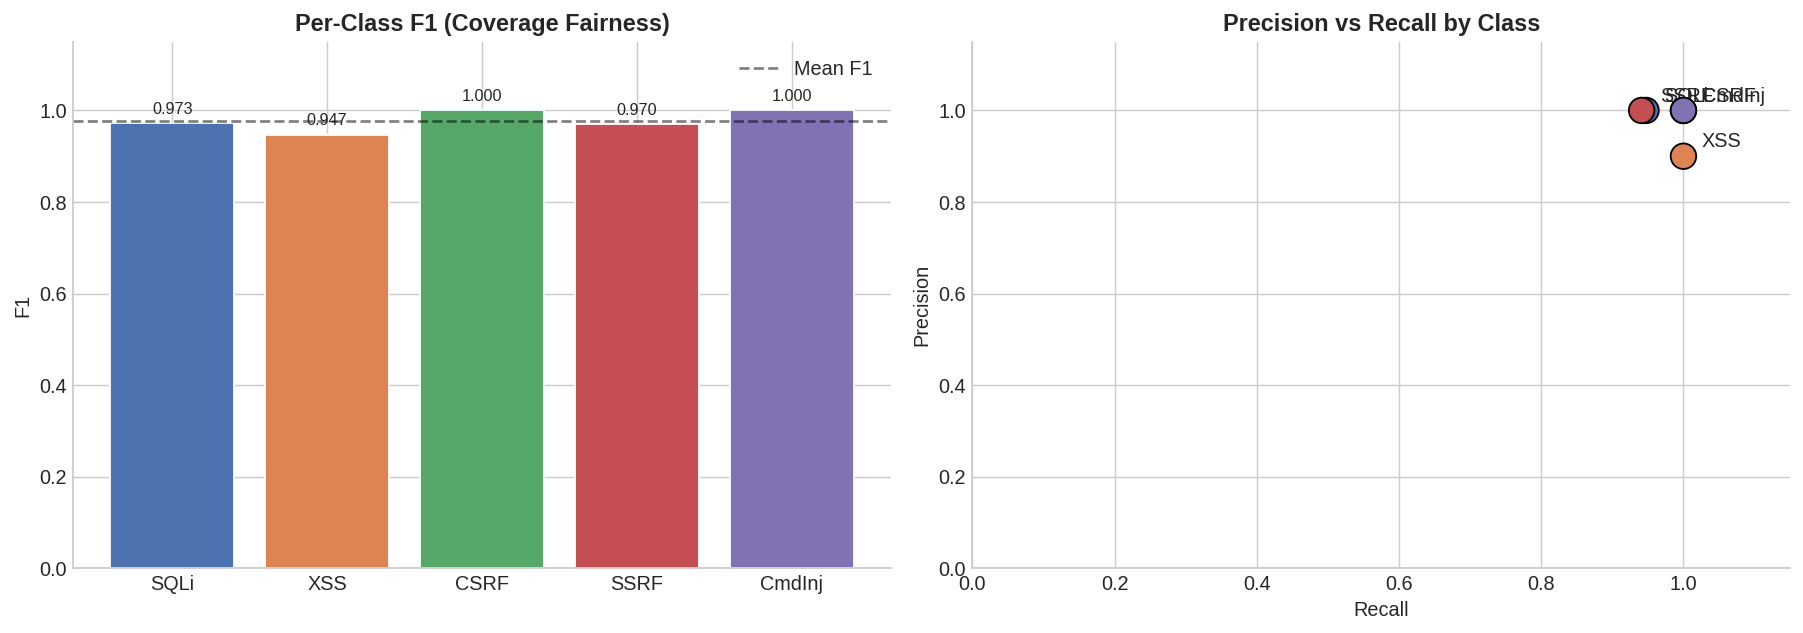

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [PALETTE[c] for c in CLASS_ORDER]

axes[0].bar(CLASS_ORDER, per_f1, color=colors, edgecolor='white')
axes[0].axhline(y=np.mean(per_f1), color='black', linestyle='--', alpha=0.5, label='Mean F1')
axes[0].set_title('Per-Class F1 (Coverage Fairness)')
axes[0].set_ylabel('F1'); axes[0].set_ylim(0, 1.15); axes[0].legend()
for i, v in enumerate(per_f1):
    axes[0].text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

axes[1].scatter(per_r, per_p, c=colors, s=200, edgecolors='black', zorder=5)
for i, c in enumerate(CLASS_ORDER):
    axes[1].annotate(c, (per_r[i], per_p[i]), textcoords='offset points', xytext=(10,5))
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision vs Recall by Class')
axes[1].set_xlim(0, 1.15); axes[1].set_ylim(0, 1.15)
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 7.2 Context Coverage

In [35]:
ctx_per_class = clean_df.groupby('attack_class')['context'].nunique().reindex(CLASS_ORDER)
total_ctx = clean_df['context'].nunique()
print('Unique contexts per class:')
for c in CLASS_ORDER:
    print(f'  {c:7s}: {ctx_per_class[c]:3d} ({ctx_per_class[c]/total_ctx*100:.1f}%)')

ctx_counts = np.sort(clean_df['context'].value_counts().values).astype(float)
n_c = len(ctx_counts)
gini = (2*np.sum(np.arange(1,n_c+1)*ctx_counts)/(n_c*np.sum(ctx_counts))) - (n_c+1)/n_c
print(f'\nContext Gini: {gini:.3f} ({"uneven" if gini > 0.4 else "balanced"})')

Unique contexts per class:
  SQLi   :  15 (6.5%)
  XSS    :   5 (2.2%)
  CSRF   :  50 (21.7%)
  SSRF   :  84 (36.5%)
  CmdInj :  77 (33.5%)

Context Gini: 0.480 (uneven)


## 7.3 Severity Label Bias

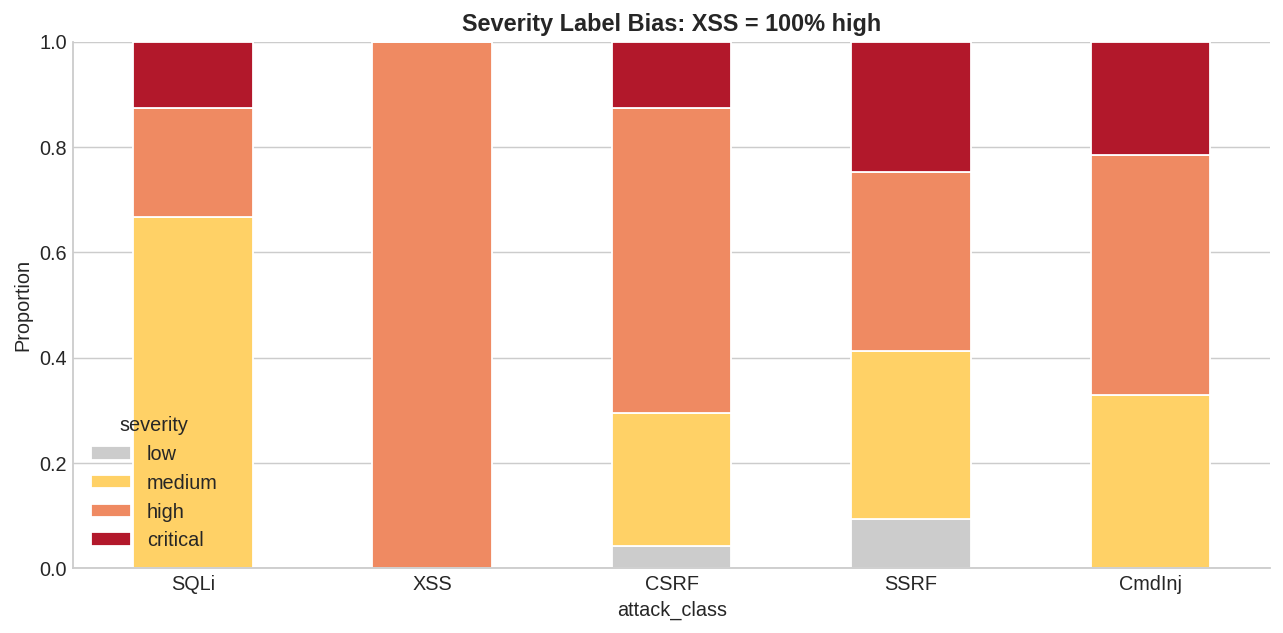

Severity entropy per class:
  SQLi   : 0.858
  XSS    : 0.000  <-- ZERO ENTROPY
  CSRF   : 1.059
  SSRF   : 1.299
  CmdInj : 1.055


In [36]:
sev_by_class = pd.crosstab(clean_df['attack_class'], clean_df['severity'], normalize='index')
for s in ['low','medium','high','critical']:
    if s not in sev_by_class.columns:
        sev_by_class[s] = 0.0
sev_by_class = sev_by_class.reindex(CLASS_ORDER)[['low','medium','high','critical']]

fig, ax = plt.subplots(figsize=(10, 5))
sev_by_class.plot(kind='bar', stacked=True, ax=ax,
    color=[SEV_COLORS[s] for s in ['low','medium','high','critical']], edgecolor='white')
ax.set_title('Severity Label Bias: XSS = 100% high')
ax.set_ylabel('Proportion'); ax.set_xticklabels(CLASS_ORDER, rotation=0)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print('Severity entropy per class:')
for c in CLASS_ORDER:
    sev_counts = df[clean_df['attack_class']==c]['severity'].value_counts()
    ent = entropy(sev_counts.values)
    flag = '  <-- ZERO ENTROPY' if ent < 0.01 else ''
    print(f'  {c:7s}: {ent:.3f}{flag}')

## 7.4 Fairness Summary

| Dimension | Status | Action |
|---|---|---|
| Class coverage | Measured from F1 | Augment if gap > 5% |
| Context coverage | Uneven | Cover all in lab testing |
| Severity labels | Confirmed bias | Never use for prioritization |
| Encoding diversity | Missing | SecLists augmentation Week 3 |

# 8. Pseudo-Model Card

**Model:** Payload Router v0.1  
**Task:** 5-class payload classification  
**Arch:** TF-IDF (char 2-5 grams) + GBM  
**Data:** ~455 unique payloads (deduplicated)  
**Eval:** 5-fold stratified CV + 20% hold-out

**Limitations:** Curated data, no encoding diversity, severity bias, small corpus.  
**Risks:** Misclassification → wrong detector → missed vuln. Over-confidence.  
**Ethics:** Dual-use. Scope gate is primary control, not classifier. All use authorized + logged.

# 9. References

- Deng et al. *PentestGPT.* USENIX Security 2024. arXiv:2308.06782
- Fang et al. *LLM Agents Hack Websites.* 2024. arXiv:2402.06664
- Fang et al. *One-day Vulns.* 2024. arXiv:2404.08144
- Li et al. *PentestAgent.* 2024. arXiv:2411.05185
- OWASP Top 10 for LLM (2025)
- MITRE ATLAS
- NIST AI RMF 1.0
- EU AI Act (2024/1689)
- SecLists (MIT), PayloadsAllTheThings (MIT)
- Verma & Rubin, *Fairness Definitions Explained*, 2018
- Spiekermann, *Value-Based Engineering*, 2023
- LangGraph (LangChain AI). Agent orchestration as a state graph. github.com/langchain-ai/langgraph
- Anthropic. Tool use / function calling with Claude. docs.claude.com/en/docs/build-with-claude/tool-use
- FWAF dataset (Faizan Ahmad). github.com/faizann24/Fwaf-Machine-Learning-driven-Web-Application-Firewall
- CSIC 2010 HTTP dataset. Information Security Institute, CSIC (Spanish National Research Council), 2010.